
# **Investment Replica**

## **Problem Statement**
We consider the following problem:

- There is a **secret portfolio**, a financial **black-box**, which publicly reports its returns on a regular basis (e.g., weekly, monthly, daily).
- We do **not** know either **which instruments** the portfolio contains or **what weight** each instrument has.
- We **do** know the vast investment vehicles available in the markets, such as **bonds, stocks, ETFs, funds, futures contracts**.
- Even if we don't know how the black-box processes input information, we can observe its **output**, i.e., the time series of returns.

Our goal is to **infer the structure of the black-box**, extracting information about latent variables or functions and structural parameters from observed data.

This notebook shows how to reverse-engineer such black-box portfolios by analyzing their return patterns and finding combinations of liquid instruments that can replicate their performance.

---

## **Dataset Description**
This dataset consists of financial data representing:

- **HFRX Index**: A popular index of **Hedge Funds** ([HFRX Index](https://www.hfr.com/indices)) – for those unfamiliar with hedge funds, see [Wikipedia](https://en.wikipedia.org/wiki/Hedge_fund).
- **MSCI World Index**: Global **Developed Equities** ([MSCI World](https://www.msci.com/acwi)).
- **MSCI World All Country Index**: Global **Equities (Developed and Emerging)** ([MSCI ACWI](https://www.msci.com/acwi)).
- **Barclays Bloomberg Global Aggregate Bond Index**: **Global Bonds** (Developed & Emerging, Govt & Corporate) ([Bloomberg](https://www.bloomberg.com/quote/LEGATRUU:IND)).
- **A broad range of Futures contracts** on equity indices, benchmark bonds, currencies, and commodities.

### **Available Futures Contracts**
| Symbol | Instrument |
|--------|------------------|
| RX1    | Bund (10 Yrs Ger) |
| CO1    | Brent (Oil) |
| DU1    | Schatz (2yrs Gvt Ger) |
| ES1    | S&P 500 (US Equity) |
| GC1    | Gold |
| LLL1   | MSCI Emerging Markets (EM Equity) |
| NQ1    | Nasdaq 100 (Tech Equity) |
| TP1    | Topix (Japanese Equity) |
| TU2    | 2Yrs US Treasury (US Govt) |
| TY1    | 10Yrs US Treasury (US Govt) |
| VG1    | Eurostoxx 50 (EU Equity) |

### **Additional Dataset Information**
- **Source**: Bloomberg.
- **Frequency**: Weekly data in local currency.
- **Format**: Original, raw format (but mostly clean).
- **Time Period**: October 2007 – April 2021.

---

## **Who Replicates What?**
To conduct a challenging exercise in **index replication** and explore **financial analytics**, we will attempt to replicate a **"monster index"** that we construct ourselves combining different indexes. This index will include:
- **Tens of thousands** of securities at a micro level.
- A **non-investable** black-box combination of stocks, bonds, and hedge funds.
- A **multi-currency** structure.

To create our **clone**, we will use **Futures contracts (long-short, possibly leveraging them)** because they are:
- **Cheap** ([Cost comparison](https://www.cmegroup.com/trading/equity-index/report-a-cost-comparison-of-futures-and-etfs.html#)).
- **Liquid** and **easy-to-use**.
- **Covering almost everything** ([Futures overview](https://www.marketwatch.com/tools/futures)).

For those new to finance, see: [A Trader’s Guide to Futures](https://www.cmegroup.com/education/files/a-traders-guide-to-futures.pdf).

---

**Alternative Replication Approaches**
Alternatively, you might replicate any linear combination of: HFRX Hedge Fund Index,MSCI World, MSCI ACWI, and Barclays Bloomberg Global Aggregate Bond Index.

This exercise will help us understand **index replication techniques** and gain insights into **financial market structures**.

<br>

As usual, let's start with **data ingestion and preprocessing**.

<br>


In [72]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)

# No need to mount Google Drive for local execution
print("Libraries imported successfully for local execution.")

Libraries imported successfully for local execution.


In [73]:
# Define the local path to the dataset
file_path = 'Dataset3_PortfolioReplicaStrategy.xlsx'

# Read the Excel file directly (headers are on the first row)
data_raw = pd.read_excel(file_path, header=0)

# Rename the first column to 'Date'
data_raw.rename(columns={data_raw.columns[0]: 'Date'}, inplace=True)

# Set the date column as the index and ensure it's in datetime format
data_raw['Date'] = pd.to_datetime(data_raw['Date'])
data = data_raw.set_index('Date')

# Clean data to numeric (coercing any potential text/errors to NaN)
data = data.apply(pd.to_numeric, errors='coerce')

# Display the first few rows to examine the dataset structure
print("Dataset preview:")
display(data.head())

# Show basic information about the dataset
print("\nDataset information:")
display(data.info())

# Display statistical summary of the dataset
print("\nBasic statistics:")
display(data.describe())

Dataset preview:


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2007-10-23,1633.4400,414.1400,350.2138,1343.6300,113.7000,110.5156,759.0000,82.8500,1525.5000,4393.0000,2212.0000,1287.0000,1570.5000,103.3850,103.7188
2007-10-30,1663.8900,423.2600,352.5413,1356.5300,113.7900,110.6562,787.8000,87.4400,1536.0000,4476.0000,2217.7500,1323.9000,1610.5000,103.4100,103.8125
2007-11-06,1651.5900,419.5100,354.1758,1360.2000,113.7900,110.8750,823.4000,93.2600,1525.0000,4425.0000,2233.5000,1320.0000,1575.5000,103.4100,104.0469
2007-11-13,1601.8100,405.9800,357.2217,1347.1600,114.3500,111.7188,799.0000,88.8300,1483.2500,4323.0000,2066.7500,1271.0000,1440.5000,103.5950,104.3047
2007-11-20,1570.7400,398.5400,359.4446,1335.2100,114.7200,113.1562,791.4000,95.4900,1446.0000,4296.0000,2035.5000,1225.2000,1472.5000,103.8000,104.9453



Dataset information:
<class 'pandas.DataFrame'>
DatetimeIndex: 705 entries, 2007-10-23 to 2021-04-20
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MXWO      705 non-null    float64
 1   MXWD      705 non-null    float64
 2   LEGATRUU  705 non-null    float64
 3   HFRXGL    705 non-null    float64
 4   RX1       705 non-null    float64
 5   TY1       705 non-null    float64
 6   GC1       705 non-null    float64
 7   CO1       705 non-null    float64
 8   ES1       705 non-null    float64
 9   VG1       705 non-null    float64
 10  NQ1       705 non-null    float64
 11  LLL1      705 non-null    float64
 12  TP1       705 non-null    float64
 13  DU1       705 non-null    float64
 14  TU2       705 non-null    float64
dtypes: float64(15)
memory usage: 88.1 KB


None


Basic statistics:


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
count,705.0000,705.0000,705.0000,705.0000,705.0000,705.0000,705.0000,705.0000,705.0000,705.0000,705.0000,705.0000,705.0000,705.0000,705.0000
mean,1644.1257,404.1519,452.2032,1210.0921,147.2788,125.9670,1317.9028,77.0185,1960.4430,3072.1676,4526.9812,1064.4441,1277.2631,110.2213,108.6277
std,443.3904,100.9801,47.3381,73.9652,19.3185,6.2952,274.4780,26.7943,770.0706,473.8127,2900.8668,128.9547,353.5983,2.3749,1.5326
min,705.3500,176.1000,342.2471,1021.4000,110.2000,110.5156,732.7000,19.3300,689.5000,1873.0000,1072.0000,465.1000,704.0000,102.1900,103.7188
25%,1293.4300,328.7900,431.7374,1158.1500,128.9000,121.2031,1178.0000,54.2700,1314.5000,2753.0000,2244.0000,1103.6000,905.0000,109.2300,107.8711
50%,1646.6900,402.5700,456.7288,1215.2000,148.0000,126.0000,1283.0000,72.0500,1909.2500,3071.0000,3884.7500,1103.6000,1302.5000,110.8550,109.0938
75%,1978.8300,478.4100,478.1868,1254.2500,163.2400,130.3438,1499.7000,105.7800,2569.7500,3433.0000,6333.2500,1103.6000,1587.5000,111.9900,109.9062
max,2944.0500,702.9900,559.3117,1415.1100,179.3200,140.3281,2001.2000,140.6700,4132.8000,4476.0000,13975.7500,1323.9000,1978.0000,112.7200,110.5273



# **Data Exploration**

Let's analyze the potential replication targets to understand their characteristics.



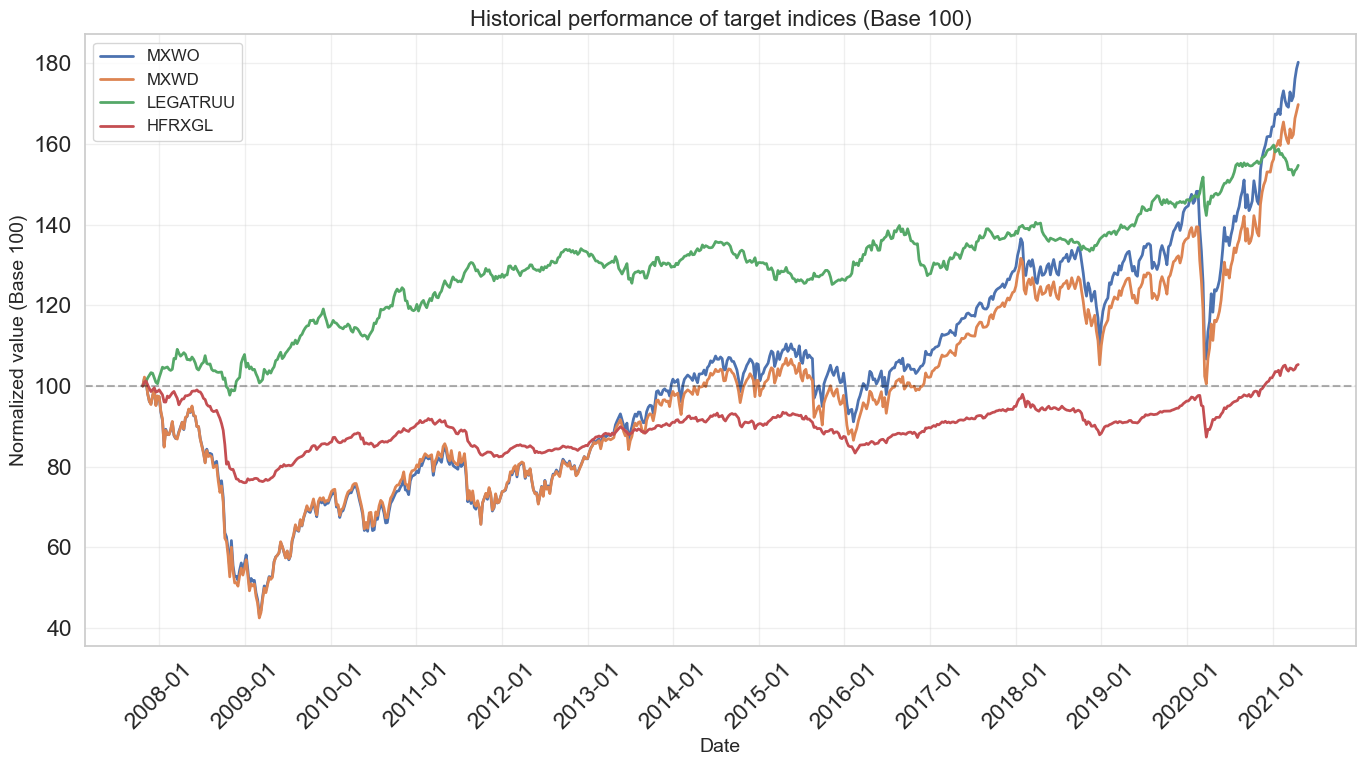


Return statistics for target indices:


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Skewness,Kurtosis
MXWO,5.90%,17.52%,0.3370,-57.61%,-0.6823,4.3570
MXWD,5.51%,17.78%,0.3097,-58.39%,-0.6413,4.6633
LEGATRUU,3.37%,5.34%,0.6305,-10.41%,-0.3297,4.1182
HFRXGL,0.50%,4.78%,0.1042,-24.91%,-2.3013,13.7023


In [74]:
import matplotlib.dates as mdates

# 3. DATA EXPLORATION


target_indices = ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL']

# This generates the exact chart you showed in the image
plt.figure(figsize=(14, 8))

for idx in target_indices:
    # Normalize to 100 at the beginning for comparison 
    normalized_series = data[idx] / data[idx].iloc[0] * 100
    plt.plot(normalized_series.index, normalized_series, linewidth=2, label=idx)

plt.title('Historical performance of target indices (Base 100)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Normalized value (Base 100)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=12)

# Format the x-axis to show dates nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

# Add a horizontal line at y=100
plt.axhline(y=100, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 3.2 Return statistics for target indices
print("\nReturn statistics for target indices:")

# Calculate weekly returns (using percentage change as in the original notebook)
returns = data[target_indices].pct_change().dropna()

# Calculate annualized statistics (assuming weekly data)
annual_factor = 52  # For weekly data (52 weeks = 1 year)

# Format as percentage with 2 decimal places
def format_pct(x):
    return f"{x*100:.2f}%"

stats = pd.DataFrame({
    'Annualized Return': returns.mean() * annual_factor,
    'Annualized Volatility': returns.std() * np.sqrt(annual_factor),
    'Sharpe Ratio': (returns.mean() * annual_factor) / (returns.std() * np.sqrt(annual_factor)),
    'Max Drawdown': returns.apply(lambda x: (1 + x).cumprod().div((1 + x).cumprod().cummax()) - 1).min(),
    'Skewness': returns.skew(),
    'Kurtosis': returns.kurtosis()
})

# Convert some columns to percentage format for better readability
for col in ['Annualized Return', 'Annualized Volatility', 'Max Drawdown']:
    stats[col] = stats[col].apply(format_pct)

# In a standard python script use print(stats), in Jupyter use display(stats)
display(stats)

### Correlation & probability distribution analysis
Understanding the shape and the relationships between different indices helps us understanding the behavior of our ingredients and identify potential replication components.

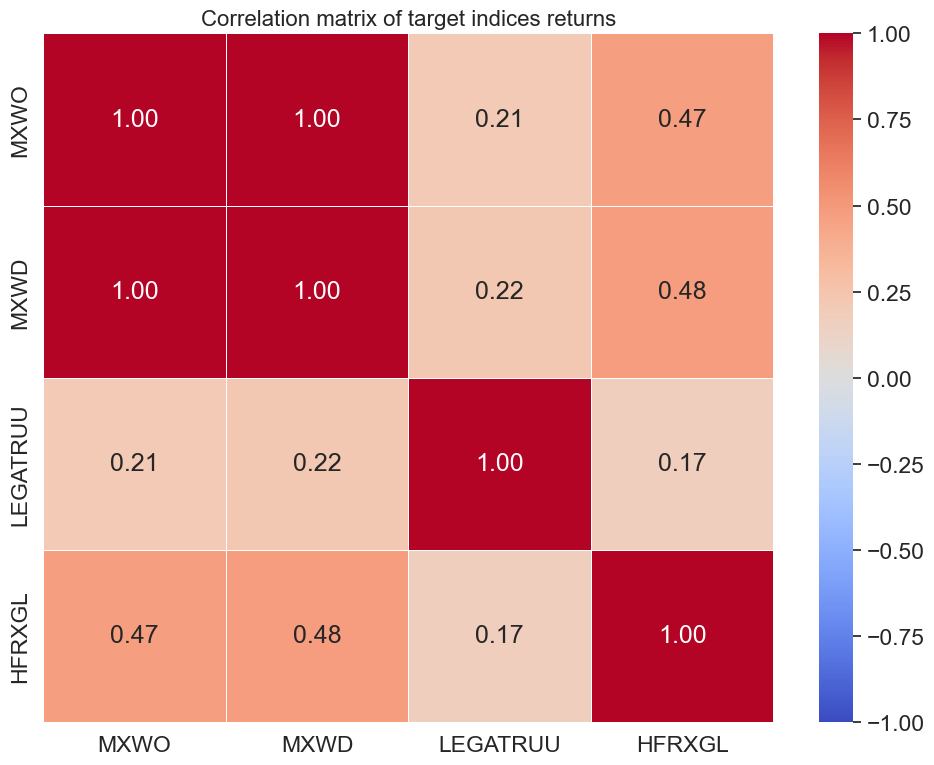

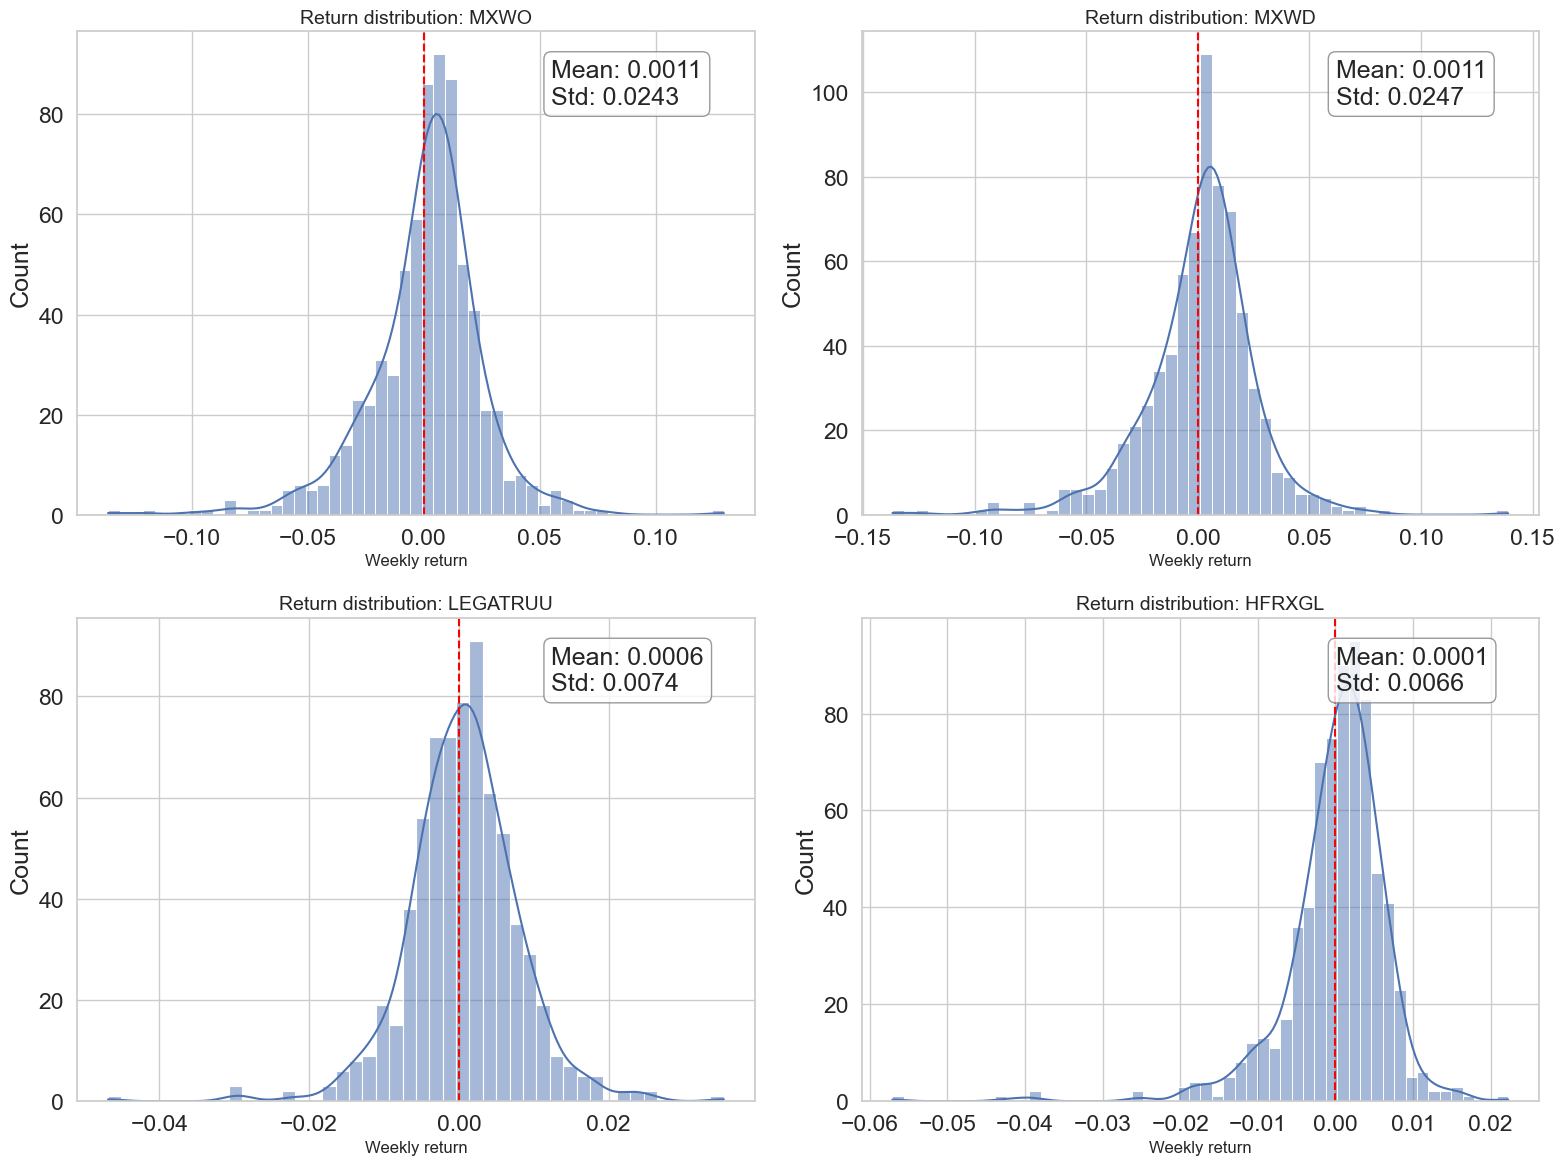

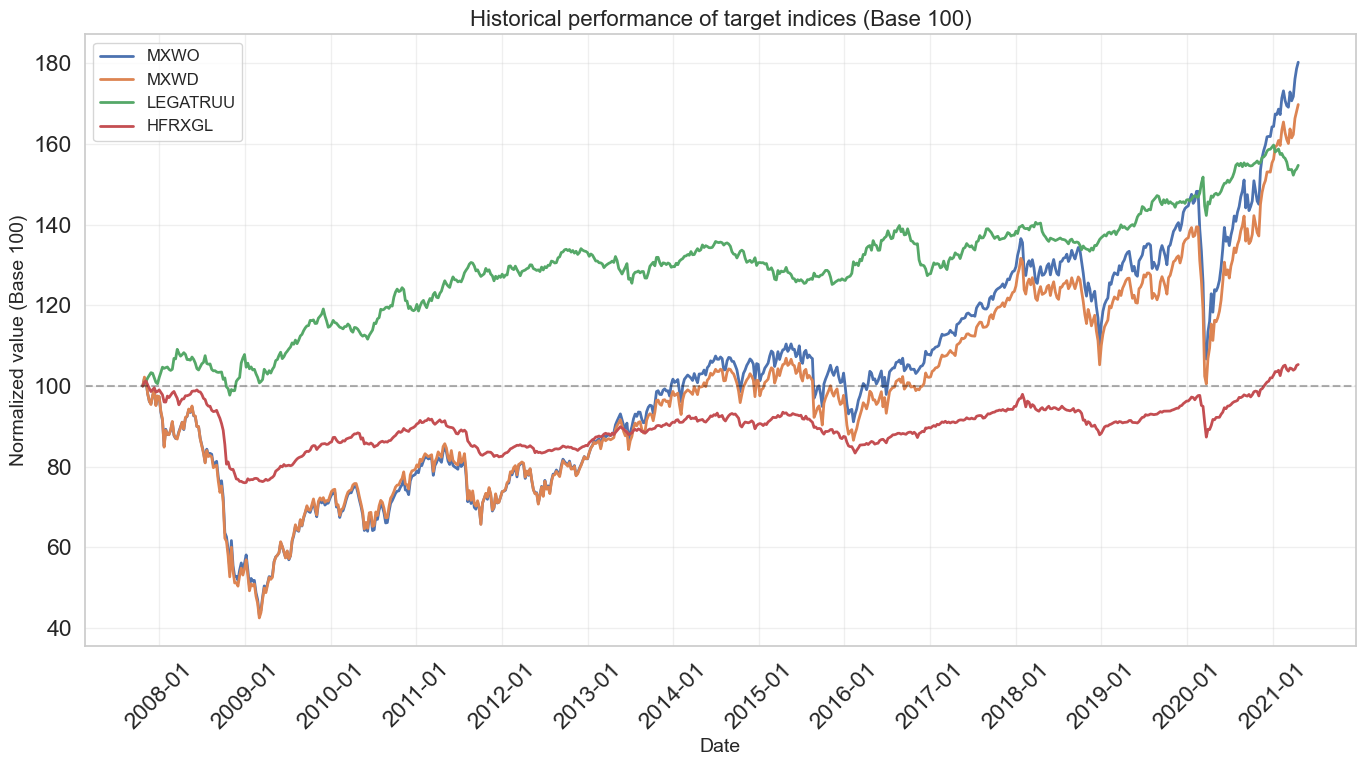

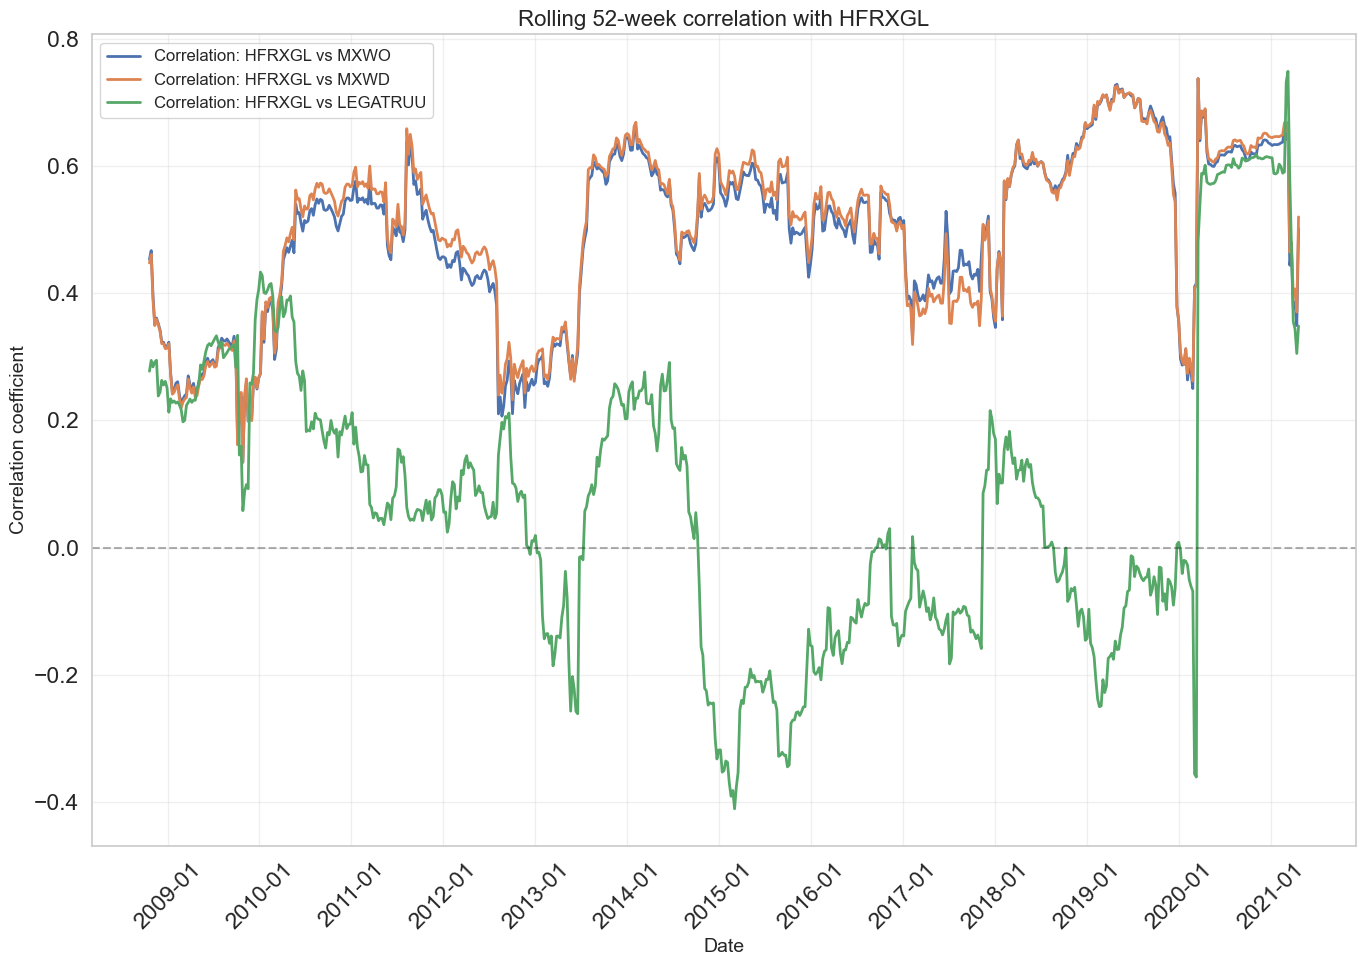

In [75]:
# 5. CORRELATION & PROBABILITY DISTRIBUTION ANALYSIS

# Create a correlation heatmap for the target indices
plt.figure(figsize=(10, 8))
correlation_matrix = returns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, fmt='.2f')
plt.title('Correlation matrix of target indices returns', fontsize=16)
plt.tight_layout()
plt.show()

# Plot returns distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, idx in enumerate(target_indices):
    sns.histplot(returns[idx], kde=True, ax=axes[i])
    axes[i].set_title(f'Return distribution: {idx}', fontsize=14)
    axes[i].set_xlabel('Weekly return', fontsize=12)
    axes[i].axvline(x=0, color='red', linestyle='--')
    
    # Add mean and std annotations
    mean = returns[idx].mean()
    std = returns[idx].std()
    axes[i].annotate(f'Mean: {mean:.4f}\nStd: {std:.4f}',
                     xy=(0.7, 0.85), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

# Plot historical performance (Rebased to 100 - CORRECTED)
plt.figure(figsize=(14, 8))
for idx in target_indices:
    # On prend les prix originaux (data) et on les rebase à 100
    normalized_series = data[idx] / data[idx].iloc[0] * 100
    plt.plot(normalized_series.index, normalized_series, linewidth=2, label=f"{idx}")

plt.title('Historical performance of target indices (Base 100)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Normalized value (Base 100)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.axhline(y=100, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot rolling correlations over time (12-month window)
rolling_window = 52  # 52 weeks ≈ 1 year
plt.figure(figsize=(14, 10))

# Base correlation against HFRXGL (Hedge Fund Index)
base_idx = 'HFRXGL'
for idx in [i for i in target_indices if i != base_idx]:
    roll_corr = returns[[base_idx, idx]].rolling(rolling_window).corr().unstack()[base_idx][idx]
    plt.plot(roll_corr.index, roll_corr, linewidth=2, label=f"Correlation: {base_idx} vs {idx}")

plt.title(f'Rolling {rolling_window}-week correlation with {base_idx}', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Correlation coefficient', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<br>

Let's examine the statistical properties of our target indices.


Correlation of Futures with Target Index:


,Correlation with Target
ES1,0.4411
TP1,0.3946
NQ1,0.3906
VG1,0.3417
CO1,0.2779


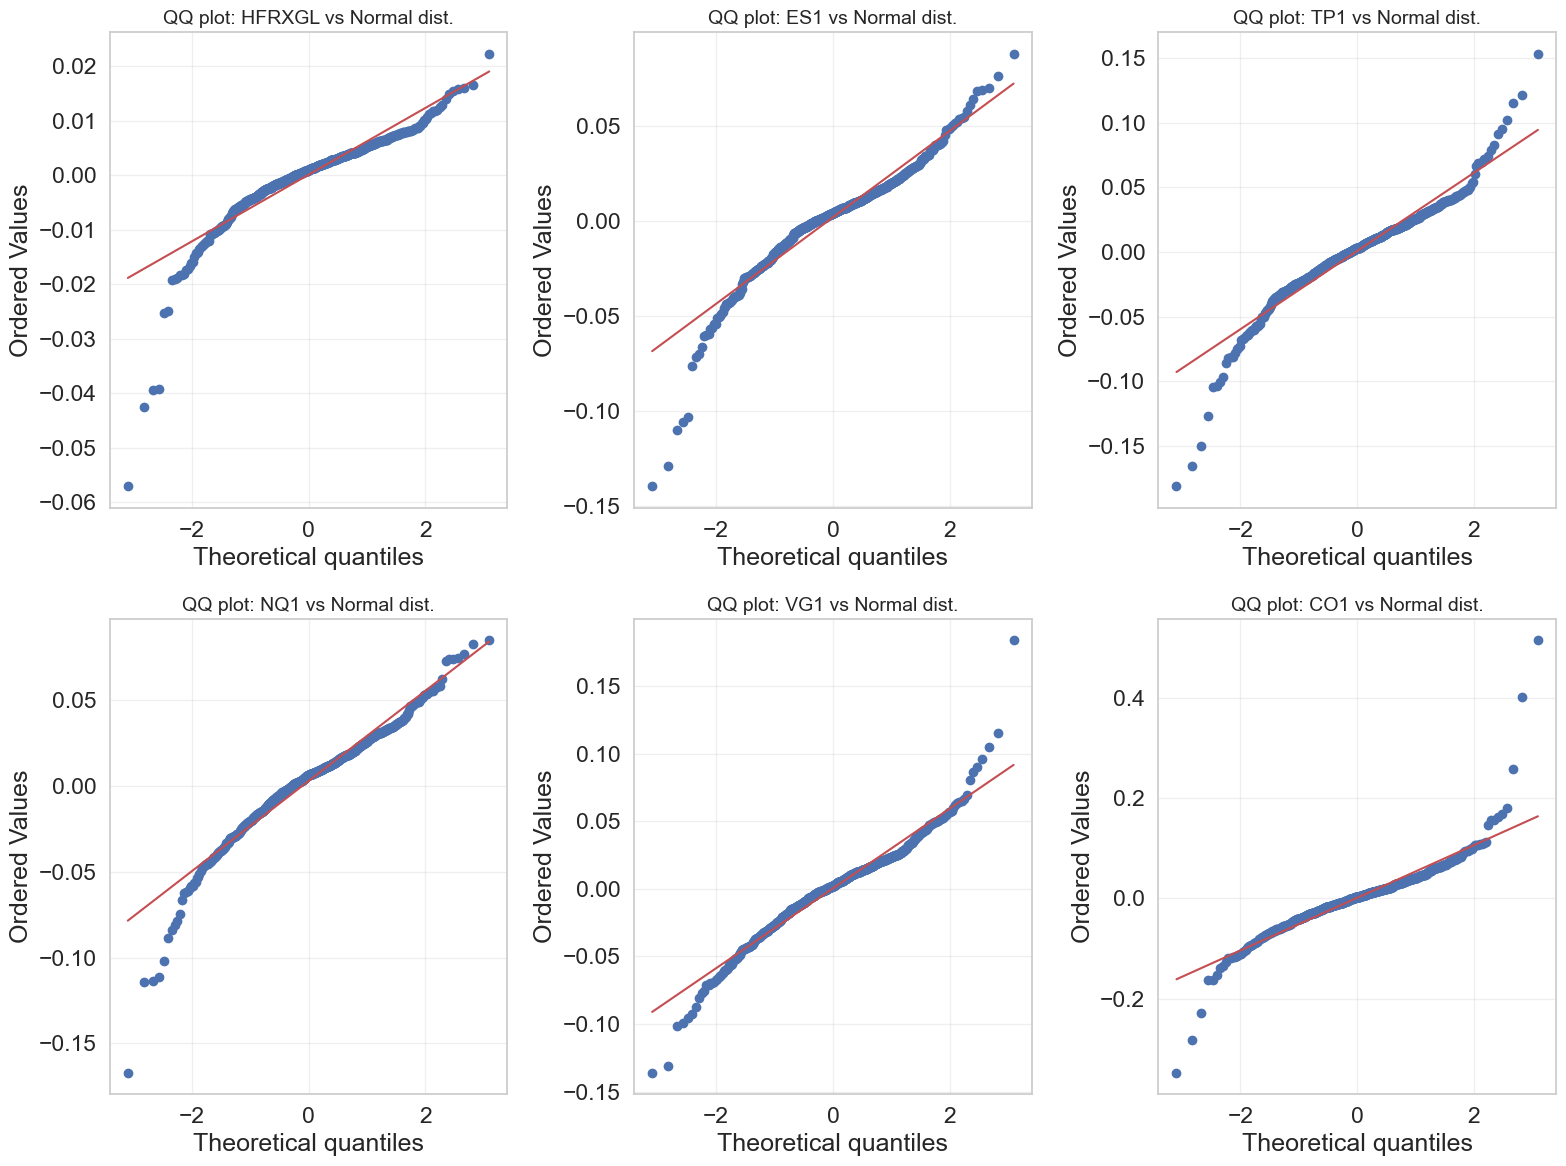

In [76]:
import scipy.stats as stats
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in divide")


# 6. QQ PLOTS ANALYSIS 


# Identify Target and Predictors
target_col = 'HFRXGL'
futures_contracts = ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']

# RECALCULATE returns for both target and futures 
all_returns = data[[target_col] + futures_contracts].pct_change().dropna()

target_returns = all_returns[target_col]
futures_returns = all_returns[futures_contracts]

# Calculate correlations to find the most relevant futures
correlations = pd.DataFrame(index=futures_contracts, columns=['Correlation with Target'])

for contract in futures_contracts:
    correlations.loc[contract] = target_returns.corr(futures_returns[contract])

correlations['Abs correlation'] = correlations['Correlation with Target'].abs()
correlations = correlations.sort_values('Abs correlation', ascending=False)
correlations = correlations.drop('Abs correlation', axis=1)

print("Correlation of Futures with Target Index:")
display(correlations.head())

# Create QQ plots
plt.figure(figsize=(16, 12))

# Plot QQ plot for the target index
plt.subplot(2, 3, 1)
stats.probplot(target_returns, dist="norm", plot=plt)
plt.title(f'QQ plot: {target_col} vs Normal dist.', fontsize=14)
plt.grid(True, alpha=0.3)

# Select top 5 futures contracts by absolute correlation
top_futures = correlations.index[:5].tolist()

# Create QQ plots for these top futures
for i, contract in enumerate(top_futures):
    plt.subplot(2, 3, i+2)
    
    # Get returns data for this contract
    returns_data = futures_returns[contract].dropna()
    
    # Create QQ plot
    stats.probplot(returns_data, dist="norm", plot=plt)
    
    plt.title(f'QQ plot: {contract} vs Normal dist.', fontsize=14)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [77]:
# Print the top correlated futures, just for reference
print("Top futures contracts by correlation with target index:")
display(correlations.head())

Top futures contracts by correlation with target index:


,Correlation with Target
ES1,0.4411
TP1,0.3946
NQ1,0.3906
VG1,0.3417
CO1,0.2779


<br>

We'll analyze the **autocorrelation** properties of our target indices to understand their time series behavior. It is possible to take this into account in modelling, and in any case it is better to know what the situation is.

<br>

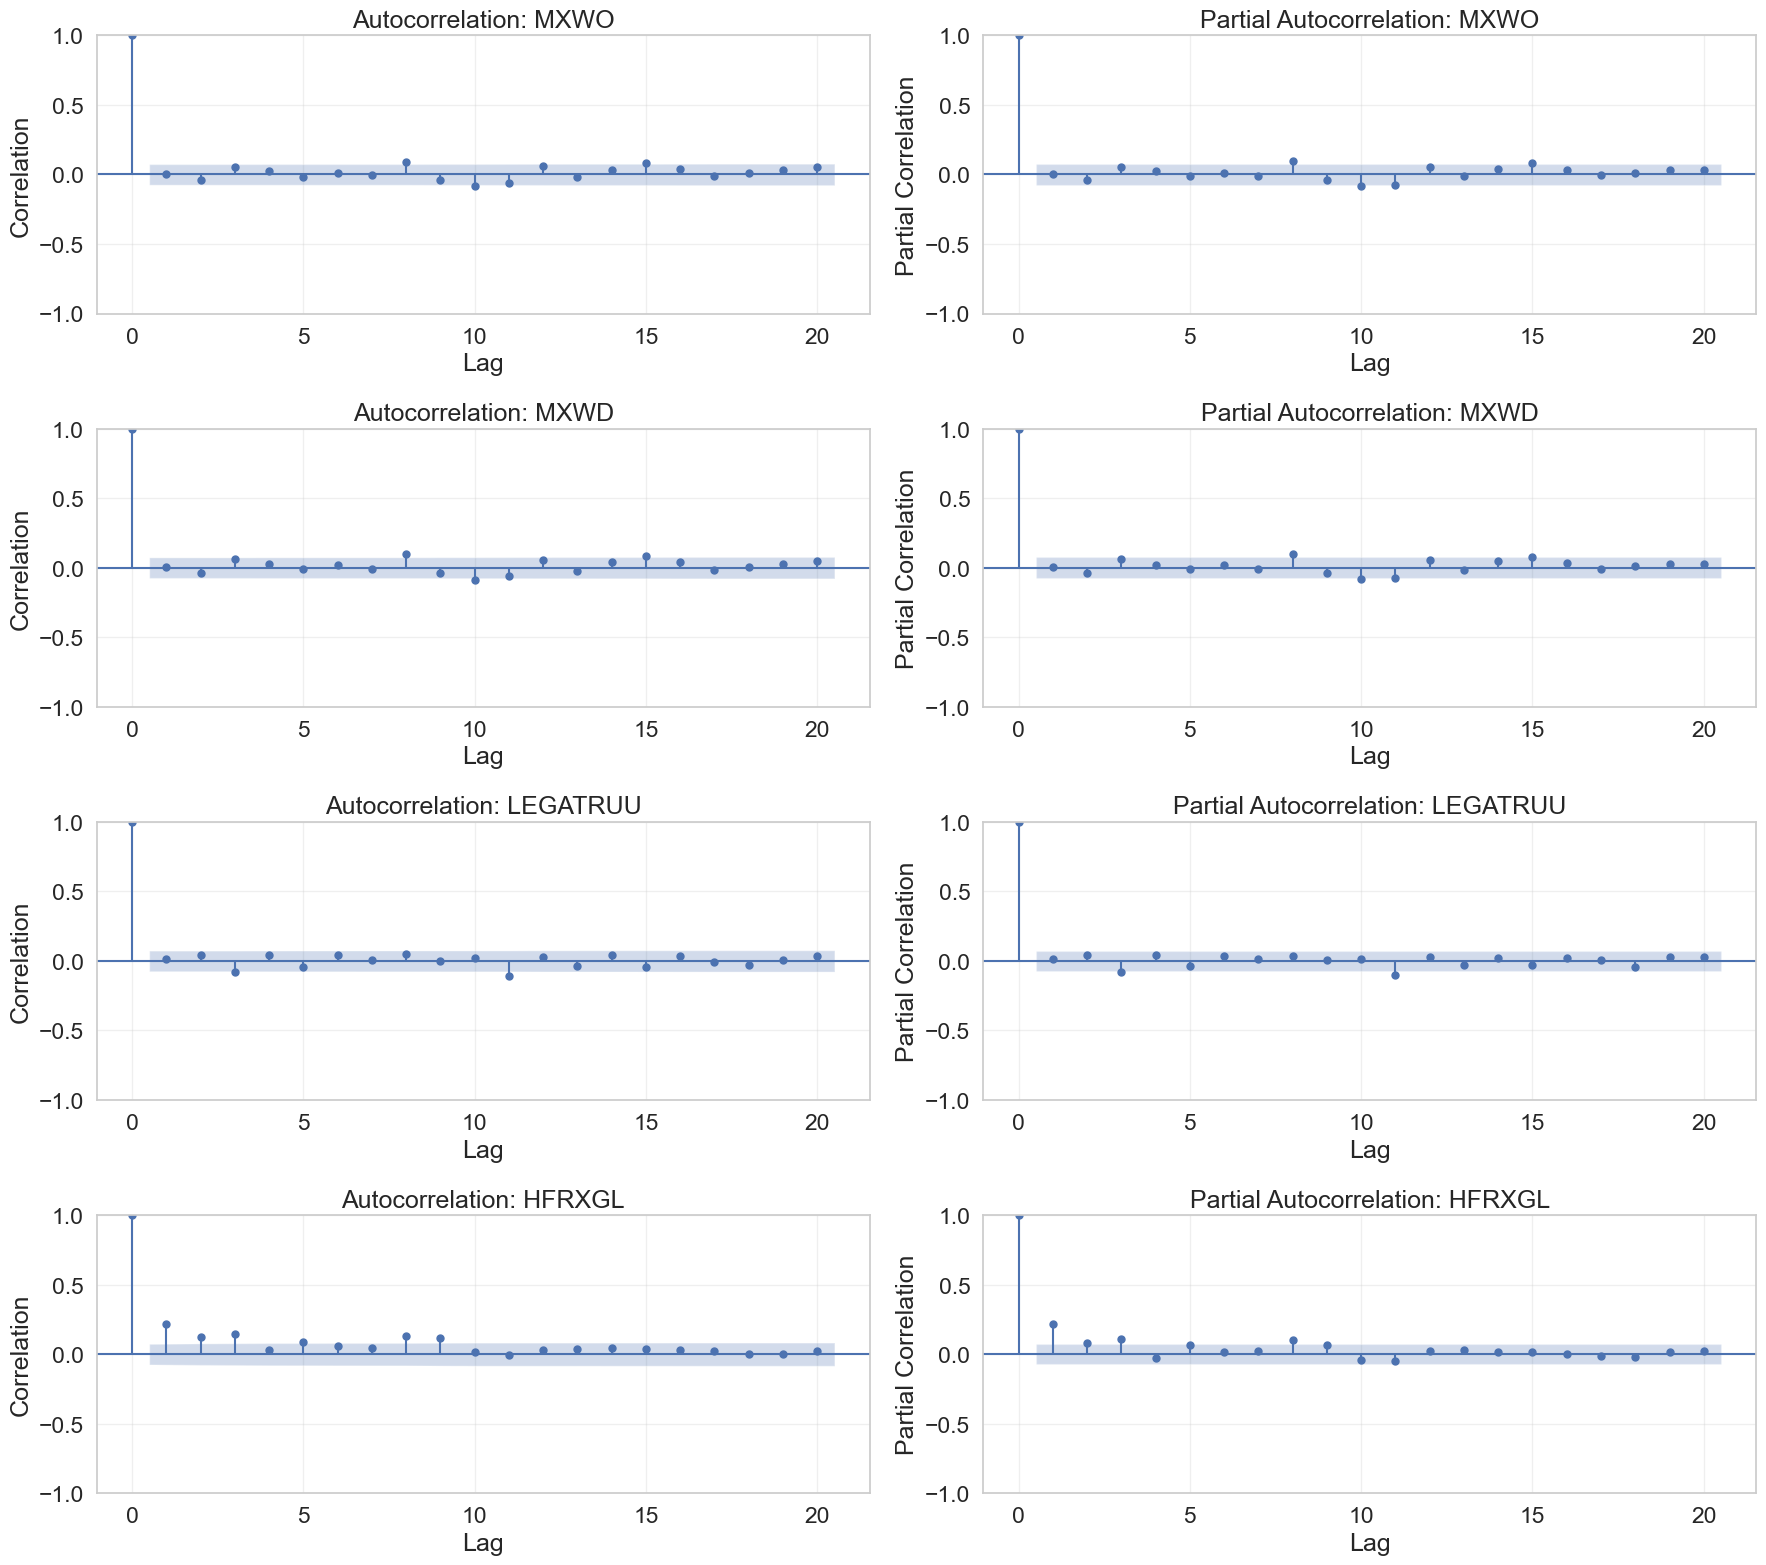

In [78]:
# Autocorrelation and Partial Autocorrelation analysis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Define the maximum number of lags to analyze
max_lags = 20

# Create a figure for ACF and PACF plots
fig, axes = plt.subplots(len(target_indices), 2, figsize=(18, 4*len(target_indices)))

# For each target index
for i, idx in enumerate(target_indices):
    # Get returns data for this index
    returns_data = returns[idx].dropna()

    # Plot ACF (Autocorrelation Function)
    plot_acf(returns_data,
             lags=max_lags,
             ax=axes[i, 0],
             title=f'Autocorrelation: {idx}',
             alpha=0.05)  # 95% confidence intervals

    axes[i, 0].set_xlabel('Lag')
    axes[i, 0].set_ylabel('Correlation')
    axes[i, 0].grid(True, alpha=0.3)

    # Plot PACF (Partial Autocorrelation Function)
    plot_pacf(returns_data,
              lags=max_lags,
              ax=axes[i, 1],
              title=f'Partial Autocorrelation: {idx}',
              alpha=0.05)  # 95% confidence intervals

    axes[i, 1].set_xlabel('Lag')
    axes[i, 1].set_ylabel('Partial Correlation')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Some **statistical tests for Autocorrelation**:
Let's perform formal statistical tests to check for autocorrelation in our return series.

In [79]:
# Ljung-Box test for autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\nLjung-Box test for Autocorrelation (H0: No autocorrelation)")
for idx in target_indices:
    # Get returns data for this index
    returns_data = returns[idx].dropna()

    # Perform Ljung-Box test for different lags
    lb_test = acorr_ljungbox(returns_data, lags=[5, 10, 15, 20])

    print(f"\n{idx}:")
    print(f"  Lag 5:  Test Statistic = {lb_test.iloc[0, 0]:.4f}, p-value = {lb_test.iloc[0, 1]:.4f}")
    print(f"  Lag 10: Test Statistic = {lb_test.iloc[1, 0]:.4f}, p-value = {lb_test.iloc[1, 1]:.4f}")
    print(f"  Lag 15: Test Statistic = {lb_test.iloc[2, 0]:.4f}, p-value = {lb_test.iloc[2, 1]:.4f}")
    print(f"  Lag 20: Test Statistic = {lb_test.iloc[3, 0]:.4f}, p-value = {lb_test.iloc[3, 1]:.4f}")



Ljung-Box test for Autocorrelation (H0: No autocorrelation)

MXWO:
  Lag 5:  Test Statistic = 3.7194, p-value = 0.5905
  Lag 10: Test Statistic = 16.3144, p-value = 0.0910
  Lag 15: Test Statistic = 27.3792, p-value = 0.0258
  Lag 20: Test Statistic = 31.2372, p-value = 0.0521

MXWD:
  Lag 5:  Test Statistic = 4.0704, p-value = 0.5393
  Lag 10: Test Statistic = 17.4323, p-value = 0.0653
  Lag 15: Test Statistic = 28.4624, p-value = 0.0188
  Lag 20: Test Statistic = 32.0118, p-value = 0.0432

LEGATRUU:
  Lag 5:  Test Statistic = 8.3823, p-value = 0.1364
  Lag 10: Test Statistic = 11.6799, p-value = 0.3071
  Lag 15: Test Statistic = 23.8265, p-value = 0.0681
  Lag 20: Test Statistic = 26.5486, p-value = 0.1484

HFRXGL:
  Lag 5:  Test Statistic = 63.9540, p-value = 0.0000
  Lag 10: Test Statistic = 90.7371, p-value = 0.0000
  Lag 15: Test Statistic = 94.7913, p-value = 0.0000
  Lag 20: Test Statistic = 96.3138, p-value = 0.0000


<br>

**Volatility Clustering Analysis**: Financial returns often exhibit volatility clustering - periods of high volatility tend to be followed by similar high volatility periods. We'll examine this phenomenon: as before, it is possible to take this into account in the modelling, and in any case it is better to know what the situation is.

<br>

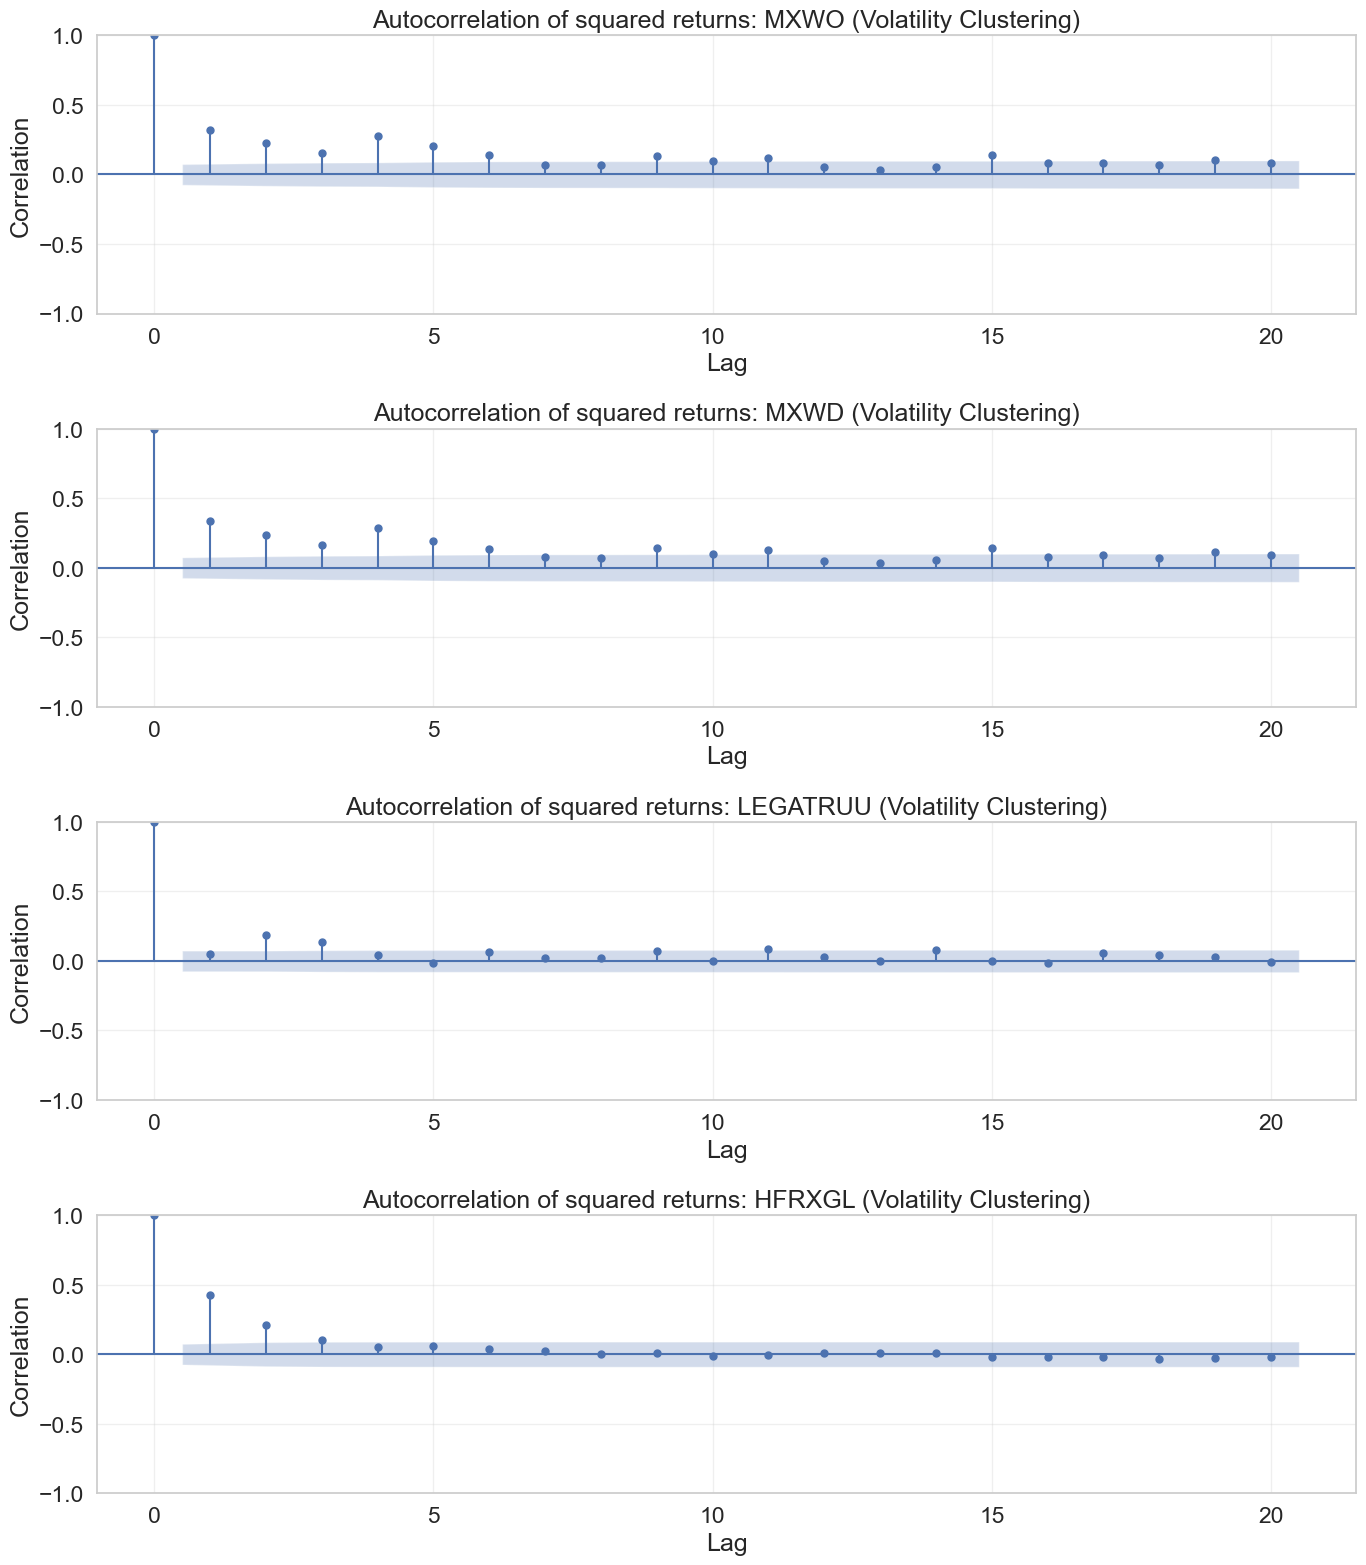

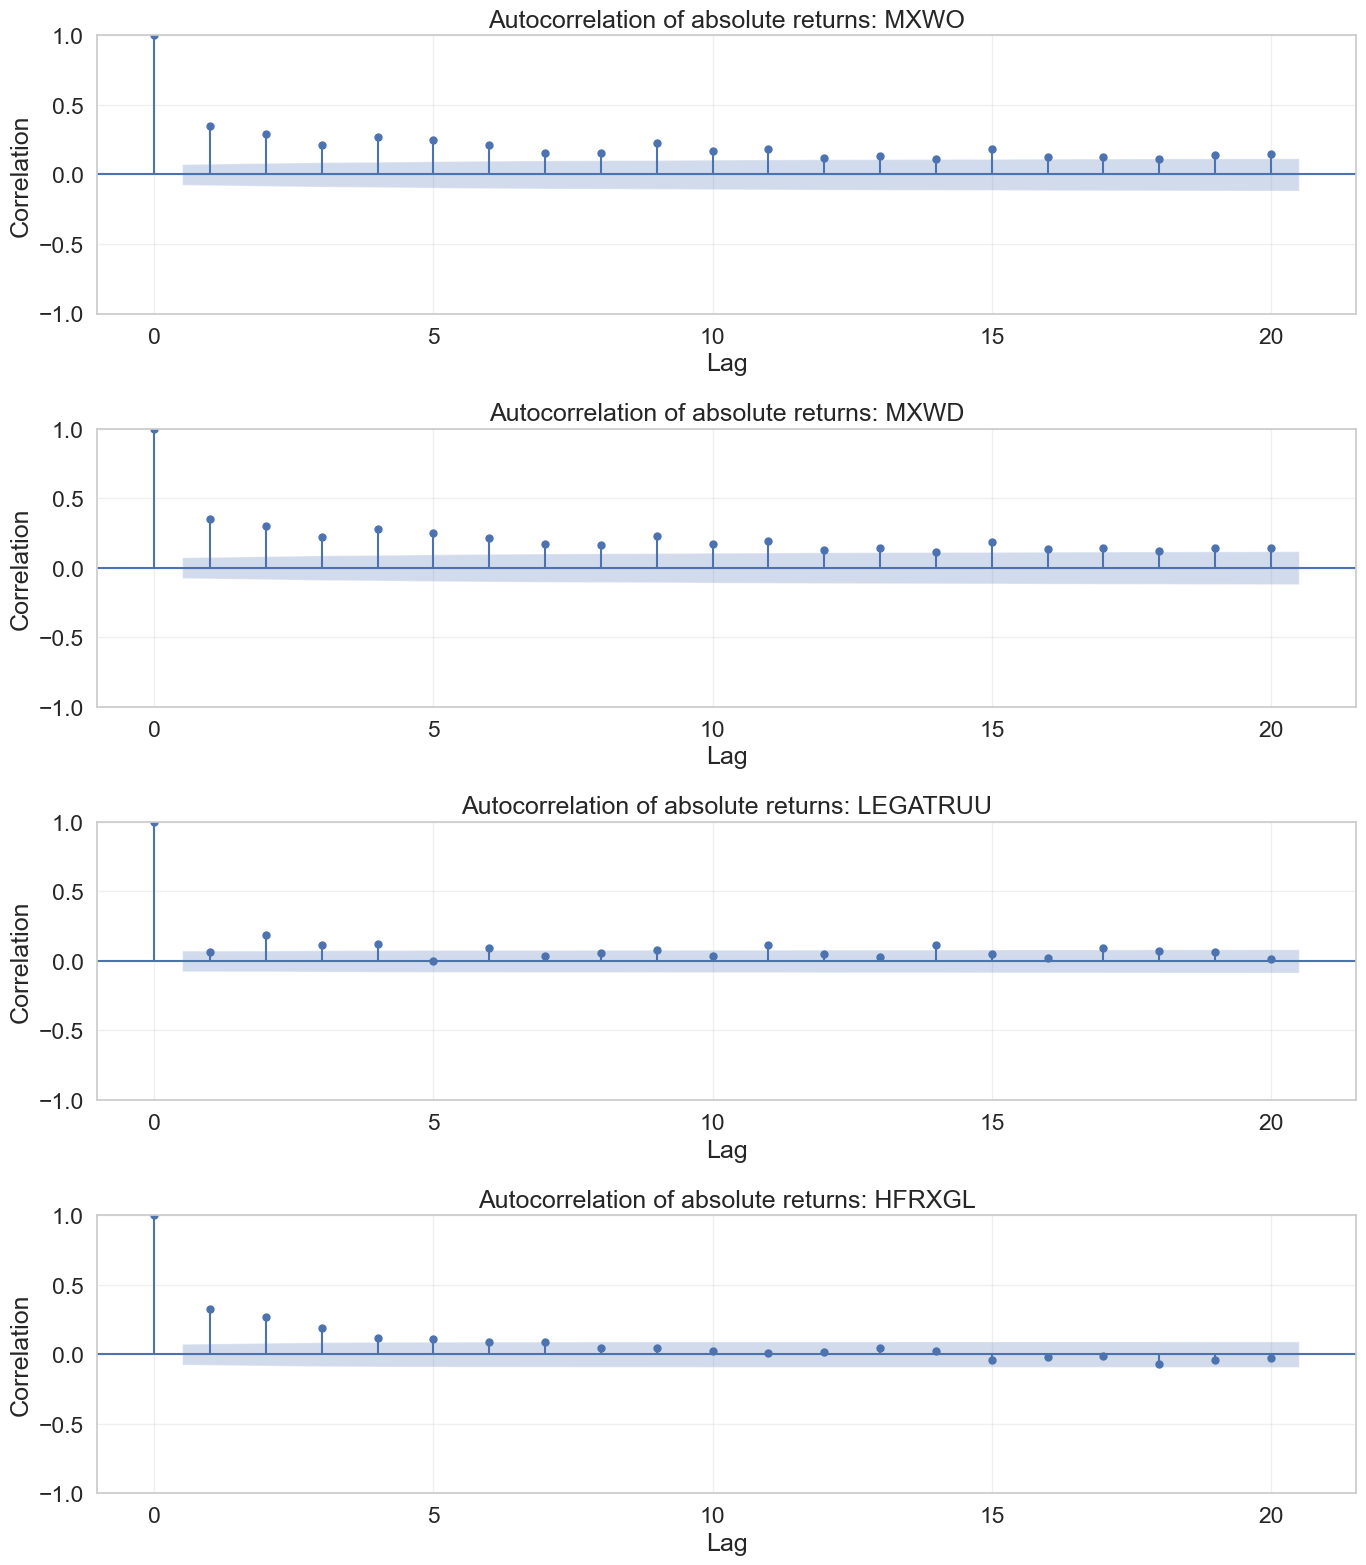

In [80]:
# Create a figure for squared returns ACF (volatility clustering)
fig, axes = plt.subplots(len(target_indices), 1, figsize=(14, 4*len(target_indices)))

# For each target index
for i, idx in enumerate(target_indices):
    # Get squared returns data for this index (for volatility clustering, ie GARC-like situations)
    squared_returns = returns[idx].dropna() ** 2

    # Plot ACF of squared returns
    plot_acf(squared_returns,
             lags=max_lags,
             ax=axes[i] if len(target_indices) > 1 else axes,
             title=f'Autocorrelation of squared returns: {idx} (Volatility Clustering)',
             alpha=0.05)  

    if len(target_indices) > 1:
        axes[i].set_xlabel('Lag')
        axes[i].set_ylabel('Correlation')
        axes[i].grid(True, alpha=0.3)
    else:
        axes.set_xlabel('Lag')
        axes.set_ylabel('Correlation')
        axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create a figure for absolute returns ACF (another measure of volatility clustering)
fig, axes = plt.subplots(len(target_indices), 1, figsize=(14, 4*len(target_indices)))

for i, idx in enumerate(target_indices):
    abs_returns = abs(returns[idx].dropna())

    plot_acf(abs_returns,
             lags=max_lags,
             ax=axes[i] if len(target_indices) > 1 else axes,
             title=f'Autocorrelation of absolute returns: {idx}',
             alpha=0.05)  

    if len(target_indices) > 1:
        axes[i].set_xlabel('Lag')
        axes[i].set_ylabel('Correlation')
        axes[i].grid(True, alpha=0.3)
    else:
        axes.set_xlabel('Lag')
        axes.set_ylabel('Correlation')
        axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<br>

Now let's analyze our constructed target index, the Monster Index, and Futures contracts that are candidates to replicate it in more detail to understand its characteristics before attempting replication.

<br>

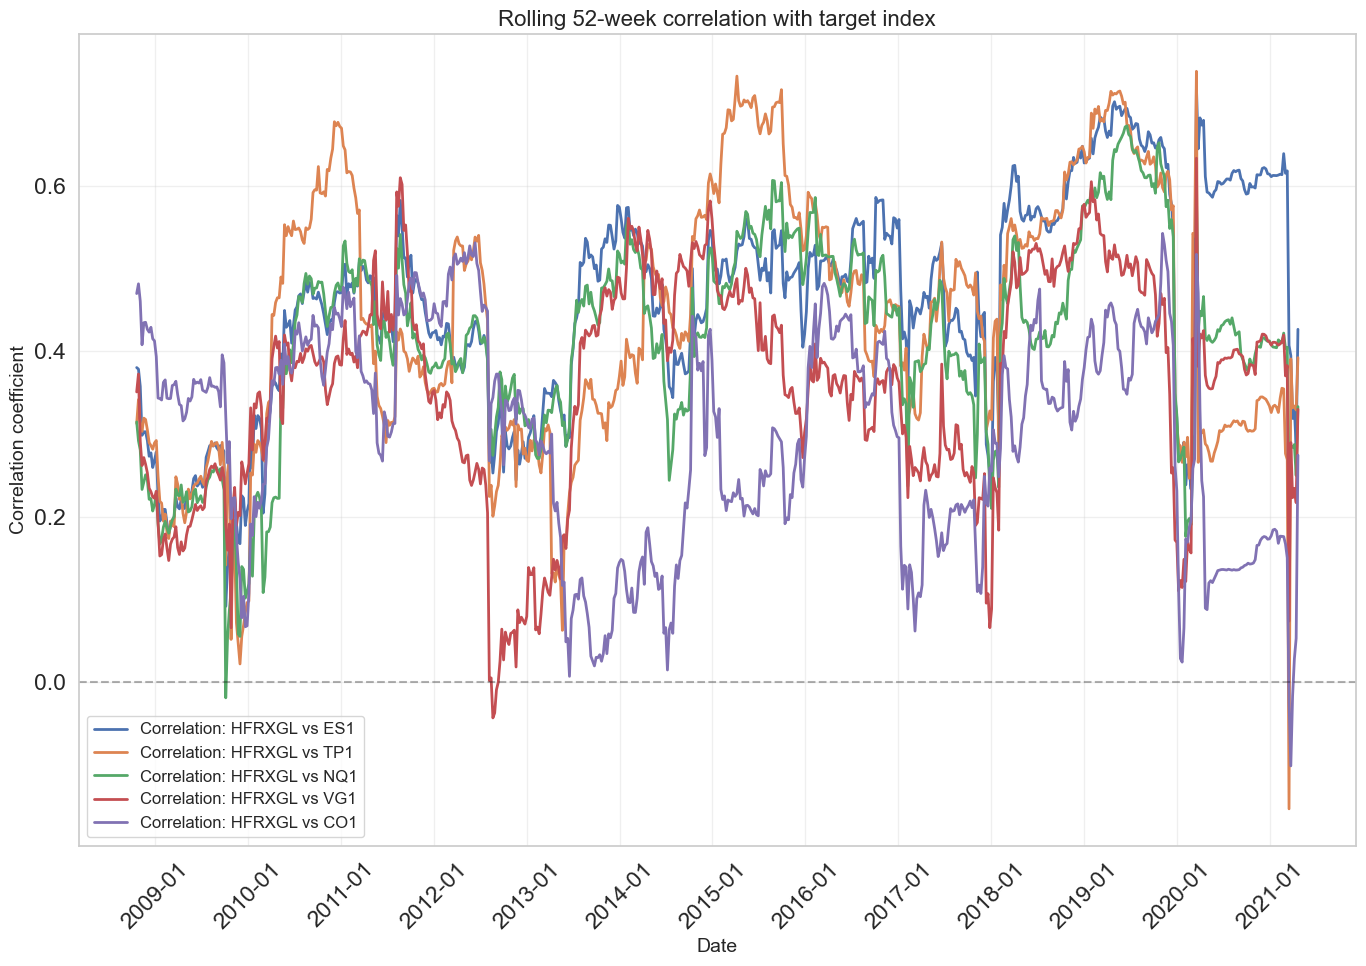

In [81]:
# 7. ROLLING CORRELATIONS ANALYSIS

# Plot rolling correlations over time (12-month window)
rolling_window = 52  # 52 weeks ≈ 1 year
plt.figure(figsize=(14, 10))

for contract in top_futures:
    # Calculate rolling correlation
    combined_df = pd.DataFrame({
        'Target': target_returns,  
        'Future': futures_returns[contract]
    })
    rolling_corr = combined_df['Target'].rolling(rolling_window).corr(combined_df['Future'])
    
    # Plot
    plt.plot(rolling_corr.index, rolling_corr, linewidth=2, 
             label=f"Correlation: {target_col} vs {contract}")

plt.title(f'Rolling {rolling_window}-week correlation with target index', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Correlation coefficient', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

If you look at the time series and their correlations with the target, they have heterogeneous paths, so it's intuitive that they can be of help, if we want to replicate complex assets, such as our "Monster Index".

In [82]:
# 8. TARGET INDEX PERFORMANCE STATISTICS

print(f"\n{target_col} (Target Index) weekly statistics:")
annual_factor = 52  

# Calculate statistics using the target_returns variable defined earlier
mean_return = target_returns.mean() * annual_factor
volatility = target_returns.std() * np.sqrt(annual_factor)
sharpe_ratio = mean_return / volatility
cumulative_returns = (1 + target_returns).cumprod()
drawdowns = 1 - cumulative_returns / cumulative_returns.cummax()
max_drawdown = drawdowns.max()
skewness = target_returns.skew()
kurtosis = target_returns.kurtosis()

# Display weekly statistics
stats_df = pd.DataFrame({
    'Statistic': ['Annualized return', 'Annualized volatility', 'Sharpe ratio',
                  'Max Drawdown', 'Skewness', 'Kurtosis'],
    'Value': [f"{mean_return*100:.2f}%",
              f"{volatility*100:.2f}%",
              f"{sharpe_ratio:.2f}",
              f"{max_drawdown*100:.2f}%",
              f"{skewness:.2f}",
              f"{kurtosis:.2f}"]
})

display(stats_df)

# Also calculate and display monthly returns statistics
if len(target_returns) >= 12:  # Ensure we have enough data
    monthly_returns = target_returns.resample('ME').apply(
        lambda x: (1 + x).prod() - 1)

    # Calculate monthly statistics 
    monthly_mean = monthly_returns.mean() * 12
    monthly_vol = monthly_returns.std() * np.sqrt(12)
    monthly_sharpe = monthly_mean / monthly_vol if monthly_vol > 0 else 0

    # Display monthly statistics
    print(f"\n{target_col} (Target Index) monthly return statistics:")
    monthly_stats = pd.DataFrame({
        'Statistic': ['Annualized return (monthly)',
                     'Annualized volatility (monthly)',
                     'Sharpe ratio (monthly)'],
        'Value': [f"{monthly_mean*100:.2f}%",
                 f"{monthly_vol*100:.2f}%",
                 f"{monthly_sharpe:.2f}"]
    })

    display(monthly_stats)


HFRXGL (Target Index) weekly statistics:


,Statistic,Value
0,Annualized return,0.50%
1,Annualized volatility,4.78%
2,Sharpe ratio,0.10
3,Max Drawdown,24.91%
4,Skewness,-2.30
5,Kurtosis,13.70



HFRXGL (Target Index) monthly return statistics:


,Statistic,Value
0,Annualized return (monthly),0.57%
1,Annualized volatility (monthly),6.09%
2,Sharpe ratio (monthly),0.09


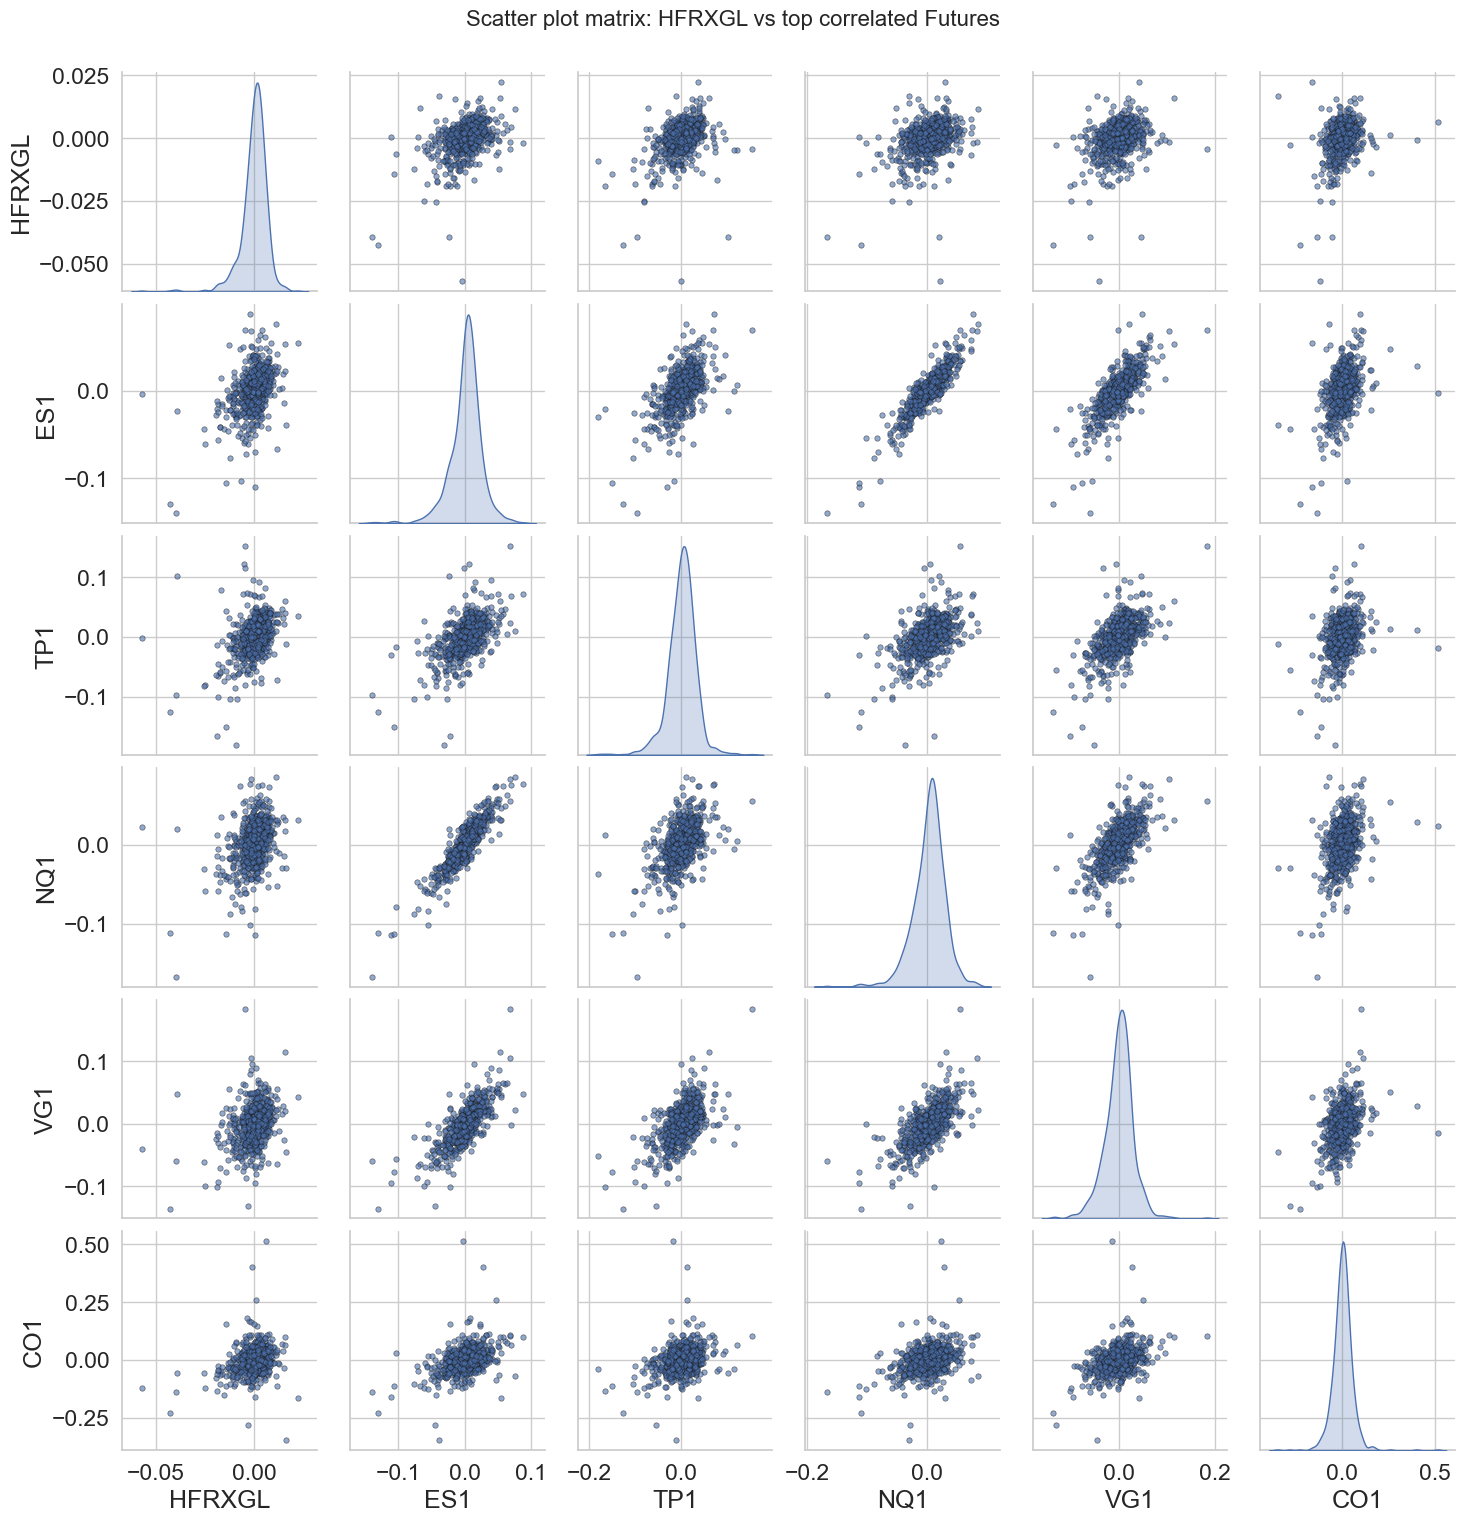

In [83]:
# Create a scatter plot matrix for the target index and top correlated futures
scatter_data = pd.concat([target_returns.rename(target_col), 
                          futures_returns[top_futures]], axis=1)

# Create a pair plot to visualize relationships
sns.pairplot(scatter_data, kind='scatter', diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 15, 'edgecolor': 'k', 'linewidth': 0.5})

plt.suptitle(f'Scatter plot matrix: {target_col} vs top correlated Futures', 
             fontsize=16, y=1.02)
plt.show()

In [84]:
import statsmodels.api as sm
import urllib.request
import zipfile
import io
import ssl
import traceback

warnings.filterwarnings("ignore")

# 10. FAMA-FRENCH 3-FACTOR ANALYSIS 


monthly_target = target_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
monthly_target.name = 'HFRXGL'
monthly_target.index = monthly_target.index.to_period('M')

# Loading Fama-French data from the web 
url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"

try:
    context = ssl._create_unverified_context()
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'})
    response = urllib.request.urlopen(req, context=context)
    
    zip_file = zipfile.ZipFile(io.BytesIO(response.read()))
    csv_name = zip_file.namelist()[0]
    
    with zip_file.open(csv_name) as f:
        lines = f.readlines()
        start_row = 0
        for i, line in enumerate(lines):
            if b'Mkt-RF' in line:
                start_row = i
                break
    
    with zip_file.open(csv_name) as f:
        ff_data = pd.read_csv(f, skiprows=start_row, index_col=0)
    
    ff_data = ff_data[ff_data.index.notna()]
    ff_data = ff_data[ff_data.index.astype(str).str.strip().str.match(r'^\d{6}$')]
    ff_data.index = pd.to_datetime(ff_data.index.astype(str).str.strip(), format='%Y%m').to_period('M')
    
    ff_data = ff_data.astype(float) / 100

    common_dates = monthly_target.index.intersection(ff_data.index)
    
    if len(common_dates) == 0:
        raise ValueError("Error: No common dates found between local file and web data.")
        
    ff_merged = pd.concat([monthly_target.loc[common_dates], ff_data.loc[common_dates]], axis=1)
    
    # Target (y): excess return (Hedge Fund - Risk-Free Rate)
    y = ff_merged['HFRXGL'] - ff_merged['RF']
    
    # Predictors (X): Facteurs Fama-French
    X = ff_merged[['Mkt-RF', 'SMB', 'HML']]
    X = sm.add_constant(X)  # Constante pour l'Alpha
    
    ff_model = sm.OLS(y, X).fit()
    
    print("Fama-French 3-Factor Model Results:")

    results_df = pd.DataFrame({
        'Coefficient': ff_model.params,
        'Std Error': ff_model.bse,
        't-Stat': ff_model.tvalues,
        'P-Value': ff_model.pvalues
    })
    
    pd.options.display.float_format = '{:.4f}'.format
    
    display(results_df)
    
    # R² 
    print("\nFiability statistics:")
    rsquared_df = pd.DataFrame({
        'Métrique': ['R-squared', 'Adjusted R-squared'],
        'Valeur': [ff_model.rsquared, ff_model.rsquared_adj]
    })
    display(rsquared_df)

except Exception as e:
    print("Error during Fama-French analysis:")
    print(traceback.format_exc())

Fama-French 3-Factor Model Results:


,Coefficient,Std Error,t-Stat,P-Value
const,-0.0025,0.0011,-2.3588,0.0196
Mkt-RF,0.2576,0.0240,10.7154,0.0000
SMB,0.0235,0.0453,0.5184,0.6049
HML,-0.0415,0.0357,-1.1619,0.2470



Fiability statistics:


,Métrique,Valeur
0,R-squared,0.4626
1,Adjusted R-squared,0.4525


In [85]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')

# 11. ROLLING ELASTIC NET & VaR CONSTRAINTS

# Ensure data is properly aligned 
y = target_returns  
X = futures_returns.loc[y.index]  

# Define hyperparameter grid
l1_ratios = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]  
rolling_windows = [52, 104, 156]            
alphas = [0.0001, 0.001, 0.01]              

# VaR parameters 
var_confidence = 0.01     
var_horizon = 4           
max_var_threshold = 0.2  

# Transaction cost rate 
transaction_cost_rate = 0.0005

# Convert to numpy arrays
X_values = X.values
y_values = y.values
dates_array = X.index.to_numpy()


def calculate_var(returns, confidence=0.01, horizon=4, method='historical'):
    """
    Calcule la Value at Risk (VaR) avec des méthodes robustes.
    method (str): 'historical' (défaut), 'modified' (Cornish-Fisher), ou 'gaussian'
    """
    returns_array = np.array(returns)
    if len(returns_array) == 0:
        return np.nan
        
    if method == 'historical':
        var_1w = -np.percentile(returns_array, confidence * 100)
        
    elif method == 'modified':
        z = stats.norm.ppf(confidence)
        s = stats.skew(returns_array)
        k = stats.kurtosis(returns_array)
        z_cf = z + (z**2 - 1)*s/6 + (z**3 - 3*z)*k/24 - (2*z**3 - 5*z)*(s**2)/36
        var_1w = -(np.mean(returns_array) + z_cf * np.std(returns_array))
        
    else: # gaussian
        z_score = stats.norm.ppf(confidence)
        var_1w = -(np.mean(returns_array) + z_score * np.std(returns_array))
        
    var = var_1w * np.sqrt(horizon)
    return var


In [86]:
# 12. BACKTEST 

def run_elastic_net_normalized(l1_ratio, rolling_window, alpha, transaction_cost_rate):
    weights_history = []     
    replica_returns = []     
    target_dates = []        
    gross_exposures = []     
    var_values = []          
    scaling_factors = []     
    turnovers = []           

    for i in range(len(X) - rolling_window - 1):
        start_idx = i
        end_idx = i + rolling_window

        X_train = X_values[start_idx:end_idx]
        y_train = y_values[start_idx:end_idx]

        scaler_X = MinMaxScaler()
        X_train_normalized = scaler_X.fit_transform(X_train)
        scaler_y = MinMaxScaler()
        y_train_normalized = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=False, max_iter=10000, tol=1e-4)
        model.fit(X_train_normalized, y_train_normalized)

        normalized_weights = model.coef_
        original_weights = normalized_weights / scaler_X.scale_
        scaling_factor = 1.0

        if len(replica_returns) >= 12:  
            historical_returns = []
            for j in range(max(0, len(replica_returns)-52), len(replica_returns)):
                hist_returns = X_values[end_idx-(len(replica_returns)-j)]
                historical_returns.append(np.dot(hist_returns, original_weights))

            var = calculate_var(historical_returns, confidence=var_confidence, horizon=1, method='modified')
            var = var * np.sqrt(var_horizon) 

            if var > max_var_threshold:
                scaling_factor = max_var_threshold / var
                original_weights = original_weights * scaling_factor
                scaled_hist = [ret * scaling_factor for ret in historical_returns]
                scaled_var = calculate_var(scaled_hist, confidence=var_confidence, horizon=1, method='modified')
                var = scaled_var * np.sqrt(var_horizon)
                
            var_values.append(var)
        else:
            var_values.append(np.nan)

        scaling_factors.append(scaling_factor)
        gross_exposure = np.sum(np.abs(original_weights))
        gross_exposures.append(gross_exposure)

        # Turnover calculation
        if len(weights_history) > 0:
            turnover = np.sum(np.abs(original_weights - weights_history[-1]))
        else:
            turnover = np.sum(np.abs(original_weights)) 
            
        turnovers.append(turnover)
        weights_history.append(original_weights)

        next_returns = X_values[end_idx]  
        gross_replica_return = np.dot(next_returns, original_weights)
        
        # Transaction cost impact
        tc_impact = turnover * transaction_cost_rate
        
        net_replica_return = gross_replica_return - tc_impact
        replica_returns.append(net_replica_return)
        
        target_dates.append(dates_array[end_idx])

    replica_returns_series = pd.Series(replica_returns, index=target_dates)
    aligned_target = y.loc[replica_returns_series.index]
    
    cumulative_target = (1 + aligned_target).cumprod()
    cumulative_replica = (1 + replica_returns_series).cumprod()

    replica_mean_return = replica_returns_series.mean() * 52  
    target_mean_return = aligned_target.mean() * 52  
    replica_vol = replica_returns_series.std() * np.sqrt(52)  
    target_vol = aligned_target.std() * np.sqrt(52)  

    replica_sharpe = replica_mean_return / replica_vol if replica_vol > 0 else 0
    target_sharpe = target_mean_return / target_vol if target_vol > 0 else 0

    tracking_error = (replica_returns_series - aligned_target).std() * np.sqrt(52)
    information_ratio = (replica_mean_return - target_mean_return) / tracking_error if tracking_error > 0 else 0

    replica_drawdown = 1 - cumulative_replica / cumulative_replica.cummax()

    return {
        'l1_ratio': l1_ratio,
        'rolling_window': rolling_window,
        'alpha': alpha,
        'transaction_cost_rate': transaction_cost_rate,
        'replica_return': replica_mean_return,
        'target_return': target_mean_return,
        'replica_vol': replica_vol,
        'target_vol': target_vol,               
        'replica_sharpe': replica_sharpe,
        'target_sharpe': target_sharpe,        
        'tracking_error': tracking_error,
        'information_ratio': information_ratio,
        'correlation': replica_returns_series.corr(aligned_target),
        'max_drawdown': replica_drawdown.max(),
        'avg_gross_exposure': np.mean(gross_exposures),
        'avg_turnover': np.mean(turnovers),
        'avg_var': np.nanmean(var_values),
        
        'cumulative_target': cumulative_target, 
        'cumulative_replica': cumulative_replica, 
        'replica_returns': replica_returns_series, 
        'gross_exposures': gross_exposures,       
        'var_values': var_values,                 
        'scaling_factors': scaling_factors        
    }


In [87]:
from itertools import product
from IPython.display import display

# 13. SUPER GRID SEARCH 

# Can add rolling fees here 

results_normalized = []

total_combinations = len(l1_ratios) * len(rolling_windows) * len(alphas) 
print(f"Lancement de la machine temporelle... Test de {total_combinations} configurations différentes !")

# Loop for each combination of hyperparameters
for i, (l1_ratio, rolling_window, alpha) in enumerate(product(l1_ratios, rolling_windows, alphas)):
    
    if i % 25 == 0 and i > 0:
        print(f"... {i} / {total_combinations} configurations testées")
        
    result = run_elastic_net_normalized(l1_ratio, rolling_window, alpha, transaction_cost_rate)
    results_normalized.append(result)

# Final results processing and display
results_df_normalized = pd.DataFrame(results_normalized)
sorted_results_normalized = results_df_normalized.sort_values(by='information_ratio', ascending=False)


columns_to_display = [
    'l1_ratio', 'rolling_window', 'alpha', 
    'information_ratio', 'correlation', 'tracking_error', 'replica_sharpe', 
    'avg_turnover'
]
display(sorted_results_normalized[columns_to_display].head(10))

# Best configuration summary
best_config_normalized = sorted_results_normalized.iloc[0]
print("\nBest Configuration :")
print(f"- L1 Ratio        : {best_config_normalized['l1_ratio']}")
print(f"- Window (weeks)  : {best_config_normalized['rolling_window']}")
print(f"- Alpha (penalty) : {best_config_normalized['alpha']}")
print(f"- Correlation     : {best_config_normalized['correlation']:.4f}")

Lancement de la machine temporelle... Test de 54 configurations différentes !
... 25 / 54 configurations testées
... 50 / 54 configurations testées


,l1_ratio,rolling_window,alpha,information_ratio,correlation,tracking_error,replica_sharpe,avg_turnover
7,0.0000,156,0.0010,0.2215,0.4136,0.0449,0.6766,0.0155
8,0.0000,156,0.0100,0.2174,0.4135,0.0436,0.7148,0.0079
6,0.0000,156,0.0001,0.2174,0.4160,0.0458,0.6467,0.0195
15,0.2000,156,0.0001,0.2102,0.4157,0.0457,0.6413,0.0192
24,0.4000,156,0.0001,0.2034,0.4162,0.0456,0.6361,0.0190
33,0.6000,156,0.0001,0.1967,0.4166,0.0455,0.6309,0.0188
42,0.8000,156,0.0001,0.1893,0.4166,0.0454,0.6247,0.0186
16,0.2000,156,0.0010,0.1888,0.4138,0.0445,0.6518,0.0148
51,1.0000,156,0.0001,0.1826,0.4168,0.0453,0.6190,0.0184
52,1.0000,156,0.0010,0.1804,0.4298,0.0433,0.6578,0.0132



Best Configuration :
- L1 Ratio        : 0.0
- Window (weeks)  : 156
- Alpha (penalty) : 0.001
- Correlation     : 0.4136



Detailed metrics for the best configuration


,Metric,Target,Replica
0,Annualized return,1.70%,2.70%
1,Annualized volatility,4.29%,3.99%
2,Sharpe ratio,0.40,0.68
3,Max Drawdown,N/A,6.13%
4,Tracking Error,N/A,4.49%
5,Information ratio,N/A,0.22
6,Correlation,N/A,0.4136
7,Average gross exposure,N/A,0.2610
8,"Average VaR (1%, 1M)",N/A,2.98%


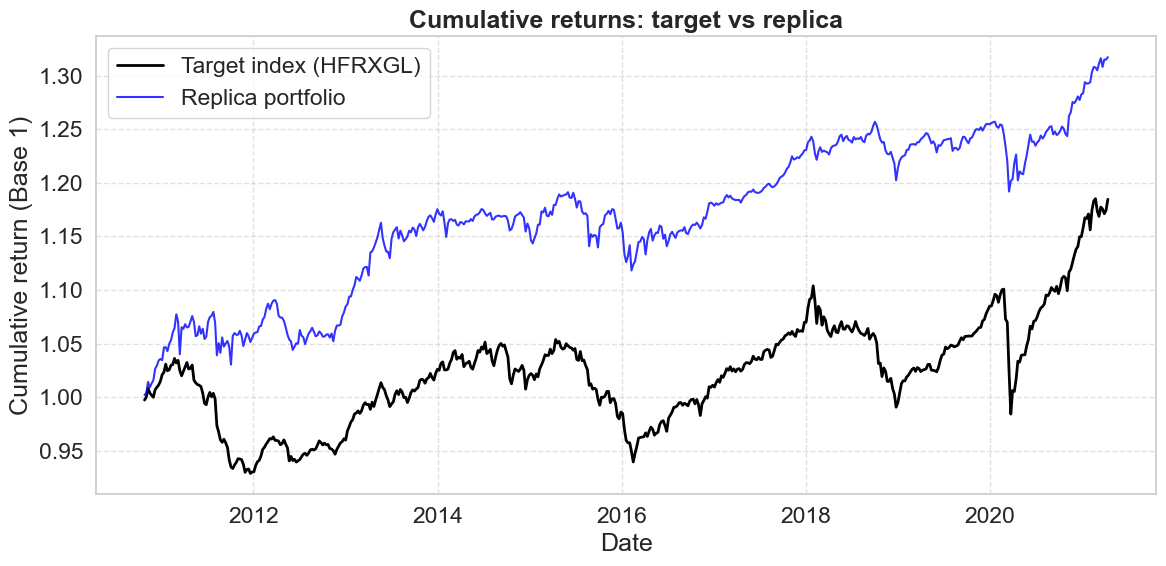

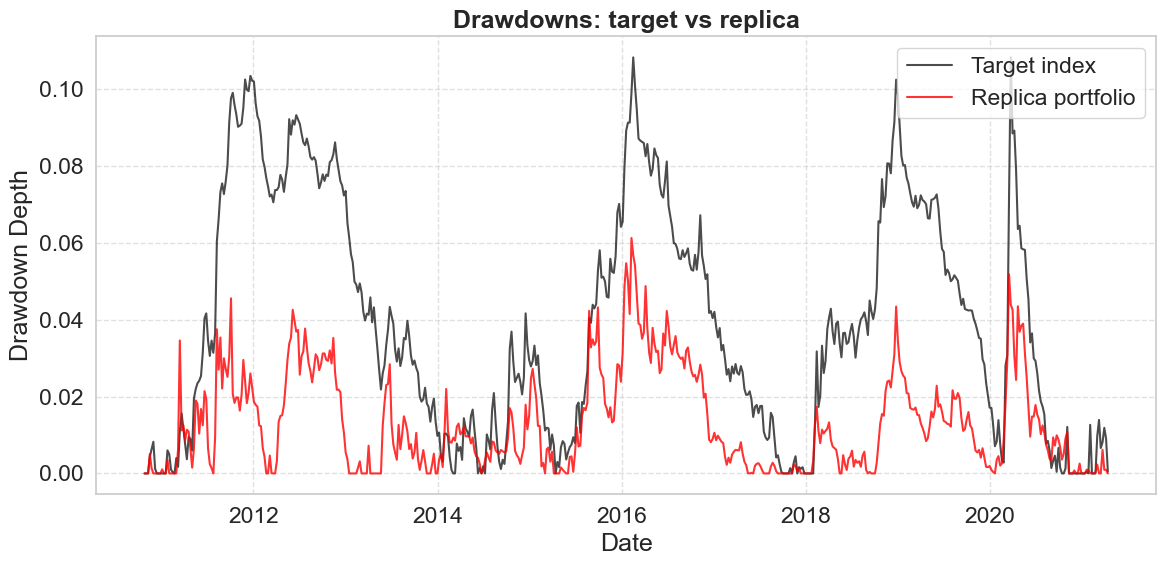

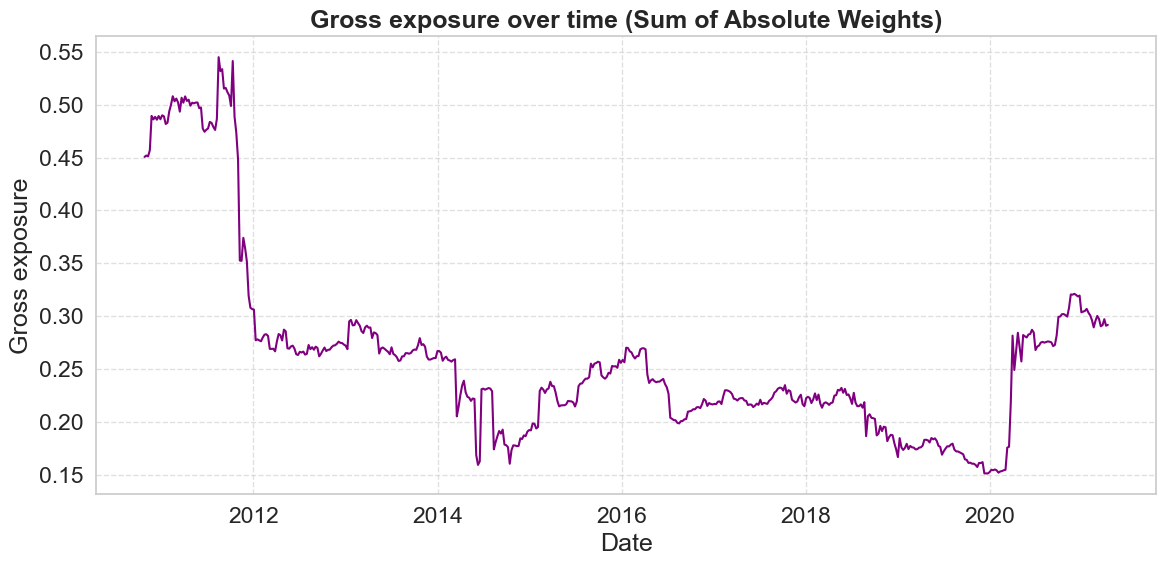

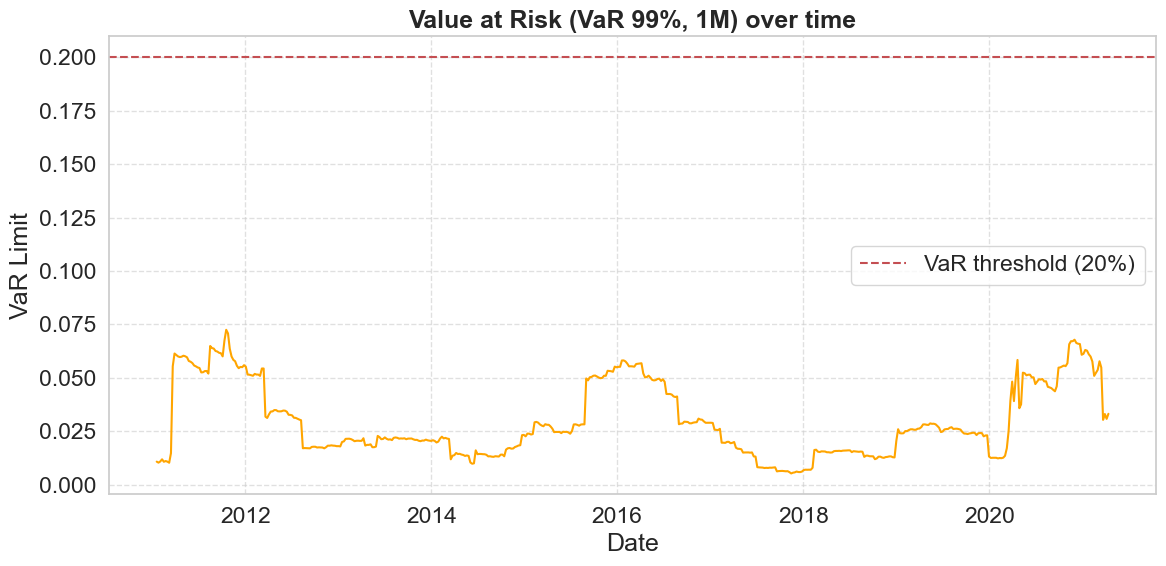

In [88]:
# 14. BEST CONFIGURATION ANALYSIS & VISUALIZATION

# Re-extract best hyperparameters
best_l1 = best_config_normalized['l1_ratio']
best_window = int(best_config_normalized['rolling_window'])
best_alpha = best_config_normalized['alpha']

try:
    best_run_data = run_elastic_net_normalized(best_l1, best_window, best_alpha, transaction_cost_rate)
except TypeError:
    best_run_data = run_elastic_net_normalized(best_l1, best_window, best_alpha)

# 3. Create a DataFrame to summarize key metrics for the best configuration
metrics_normalized = pd.DataFrame({
    'Metric': ['Annualized return', 'Annualized volatility', 'Sharpe ratio',
               'Max Drawdown', 'Tracking Error', 'Information ratio',
               'Correlation', 'Average gross exposure', 'Average VaR (1%, 1M)'],
    'Target': [f"{best_run_data['target_return']*100:.2f}%",
               f"{best_run_data['target_vol']*100:.2f}%",
               f"{best_run_data['target_sharpe']:.2f}",
               "N/A", 
               "N/A", "N/A", "N/A", "N/A", "N/A"],
    'Replica': [f"{best_run_data['replica_return']*100:.2f}%",
                f"{best_run_data['replica_vol']*100:.2f}%",
                f"{best_run_data['replica_sharpe']:.2f}",
                f"{best_run_data['max_drawdown']*100:.2f}%",
                f"{best_run_data['tracking_error']*100:.2f}%",
                f"{best_run_data['information_ratio']:.2f}",
                f"{best_run_data['correlation']:.4f}",
                f"{best_run_data['avg_gross_exposure']:.4f}",
                f"{best_run_data['avg_var']*100:.2f}%"]
})

print("\nDetailed metrics for the best configuration")
display(metrics_normalized)


# Plot 1 : Cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(best_run_data['cumulative_target'], label='Target index (HFRXGL)', color='black', linewidth=2)
plt.plot(best_run_data['cumulative_replica'], label='Replica portfolio', color='blue', alpha=0.8)
plt.title('Cumulative returns: target vs replica', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative return (Base 1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot 2 : Drawdowns
plt.figure(figsize=(12, 6))
target_drawdown = 1 - best_run_data['cumulative_target'] / best_run_data['cumulative_target'].cummax()
replica_drawdown = 1 - best_run_data['cumulative_replica'] / best_run_data['cumulative_replica'].cummax()
plt.plot(target_drawdown, label='Target index', color='black', alpha=0.7)
plt.plot(replica_drawdown, label='Replica portfolio', color='red', alpha=0.8)
plt.title('Drawdowns: target vs replica', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Drawdown Depth')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot 3 : Gross exposure over time
plt.figure(figsize=(12, 6))
if 'gross_exposures' in best_run_data:
    gross_exposure_series = pd.Series(best_run_data['gross_exposures'], index=best_run_data['replica_returns'].index)
    plt.plot(gross_exposure_series, color='purple')
    plt.title('Gross exposure over time (Sum of Absolute Weights)', fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Gross exposure')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Plot 4 : VaR over time
plt.figure(figsize=(12, 6))
if 'var_values' in best_run_data:
    var_series = pd.Series(best_run_data['var_values'], index=best_run_data['replica_returns'].index)
    plt.plot(var_series, color='orange')
    plt.axhline(y=0.20, color='r', linestyle='--', label='VaR threshold (20%)')
    plt.title('Value at Risk (VaR 99%, 1M) over time', fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('VaR Limit')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [89]:
# Kalman Filter implementation for replication 

def run_kalman_filter_clone(tc_rate=0.0005, process_noise=1e-4, obs_noise=0.1):
    n_assets = X.shape[1]
    
    # INITIALIZATION
    from sklearn.linear_model import Ridge
    init_model = Ridge(alpha=0.1).fit(X_values[:52], y_values[:52])
    
    # Initial state
    x_t = init_model.coef_ 
    # Covariance matrix of estimation error
    P_t = np.eye(n_assets) * 0.1
    
    # State parameters
    A = np.eye(n_assets)  
    Q = np.eye(n_assets) * process_noise 
    R = obs_noise           
    
    replica_returns = []
    weights_history = []
    target_dates = []
    
    # Kalman Filter
    for t in range(52, len(X_values)):
        x_pred = A @ x_t
        P_pred = A @ P_t @ A.T + Q
        
        C_t = X_values[t] 
        y_obs = y_values[t] 
        
        y_pred = np.dot(C_t, x_pred)
        innovation = y_obs - y_pred
        
        S = C_t @ P_pred @ C_t.T + R
        K = P_pred @ C_t.T / S
        
        # New weights
        x_t = x_pred + K * innovation
        P_t = (np.eye(n_assets) - np.outer(K, C_t)) @ P_pred
        
        # Net return calculation with transaction costs
        if len(weights_history) > 0:
            turnover = np.sum(np.abs(x_t - weights_history[-1]))
        else:
            turnover = np.sum(np.abs(x_t))
            
        gross_ret = np.dot(C_t, x_t)
        net_ret = gross_ret - (turnover * tc_rate)
        
        replica_returns.append(net_ret)
        weights_history.append(x_t.copy())
        target_dates.append(dates_array[t])
        
    return pd.Series(replica_returns, index=target_dates)



KALMAN FILTER CLONE :
- Annualized Return   : 1.00%
- Volatility          : 2.24%
- Sharpe Ratio        : 0.44
- Correlation         : 0.4455


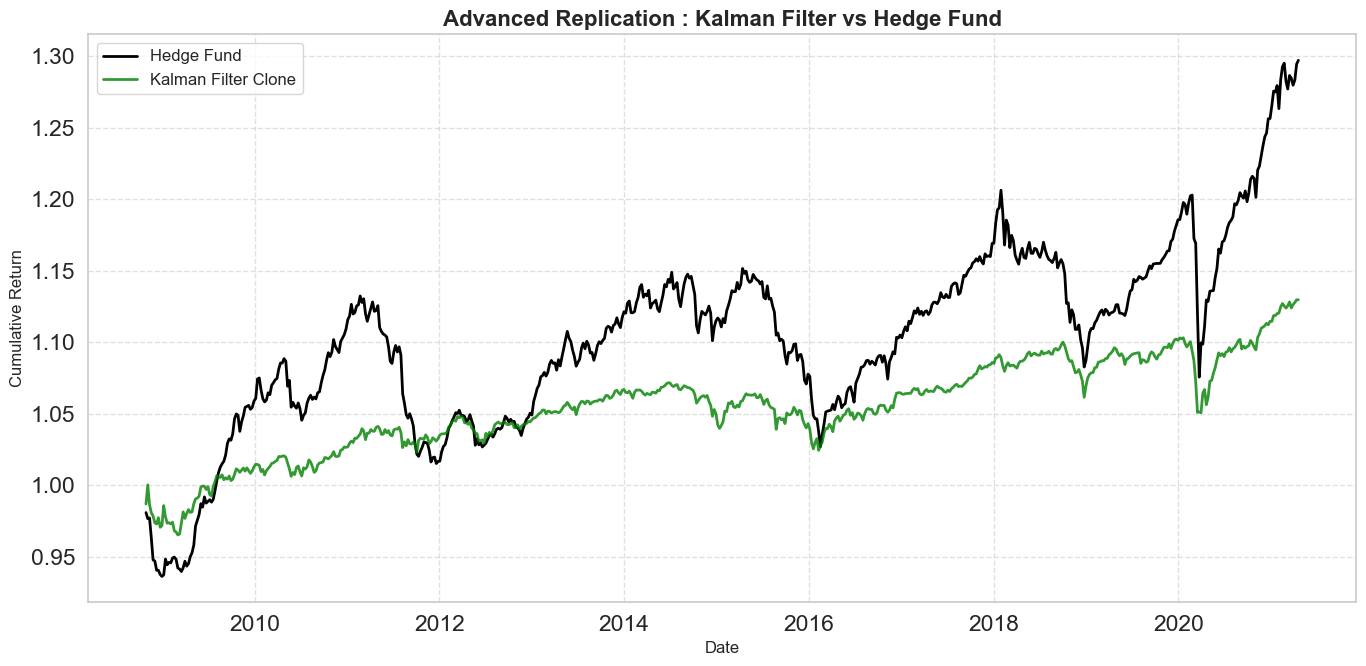

In [90]:
# 15. KALMAN FILTER CLONE ANALYSIS

kalman_returns = run_kalman_filter_clone(tc_rate=0.0005)

aligned_target_kalman = y.loc[kalman_returns.index]

cumulative_kalman = (1 + kalman_returns).cumprod()
cumulative_target_k = (1 + aligned_target_kalman).cumprod()

kalman_corr = kalman_returns.corr(aligned_target_kalman)
kalman_ann_ret = kalman_returns.mean() * 52
kalman_ann_vol = kalman_returns.std() * np.sqrt(52)
kalman_sharpe = kalman_ann_ret / kalman_ann_vol

print("\nKALMAN FILTER CLONE :")
print(f"- Annualized Return   : {kalman_ann_ret*100:.2f}%")
print(f"- Volatility          : {kalman_ann_vol*100:.2f}%")
print(f"- Sharpe Ratio        : {kalman_sharpe:.2f}")
print(f"- Correlation         : {kalman_corr:.4f}")

plt.figure(figsize=(14, 7))
plt.plot(cumulative_target_k.index, cumulative_target_k, label='Hedge Fund', color='black', linewidth=2)
plt.plot(cumulative_kalman.index, cumulative_kalman, label='Kalman Filter Clone', color='green', linewidth=2, alpha=0.8)

plt.title('Advanced Replication : Kalman Filter vs Hedge Fund', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# **HINTs**

### **Introduce transaction costs**
Consider 5 basis points (0.05%) per trade, it is a reasonable average value.

### **Try different algorithms**
* **Try different related models, such as OLS, Lasso, Ridge**, testing:
    * Different rolling windows.
    * Different rebalancing windows (every N weeks, eg 4 weeks, 12 weeks).
    * Different hyperparameters, eg lambda, Alpha.
    * some Futures selction before the regression.

* **Try a Kalman Filter**

If you have already studied **State Space Models** and the **Kalman Filter**, here’s a more advanced idea for portfolio replication.

##### Problem Setting

We want to replicate a **target portfolio return** using a dynamic linear model, where the **portfolio weights are unobservable** and potentially changing over time.

This naturally leads to a **linear multivariate Gaussian State-Space Model**:

#### State-Space representation

We define:

- $y_t$: target portfolio return from $t-1$ to $t$ = **observable scalar**.
- $x_t$: portfolio weights at time $t% = **unobservable vector**.
- $C_t$: observed asset returns (Futures contracts) — ** a vector**.

$
\begin{aligned}
x_t &= A x_{t-1} + B u_t \quad &\text{(state equation)} \\
y_t &= C_t x_t + D \varepsilon_t \quad &\text{(observation equation)}
\end{aligned}
$

---

#### Parameter (reasonable) choices

- $A = I$: identity matrix — assumes **weights follow a random walk**.
- $B$: diagonal matrix of process noise (std. dev. of innovations in weights).
- $C_t$: observed Futures returns at time $t$ .
- $D$: standard deviation of target portfolio return.

This setup assumes that weights evolve **slowly and stochastically**, while returns are a linear combination of the current weights and observable market data.


> 💡 Hint: Start with a Ridge regression (or similar) to **initialize the first weight vector**, then let the Kalman Filter take over.

---

- See: [What is the Kalman Filter? (MathWorks)](https://it.mathworks.com/help/econ/what-is-the-kalman-filter.html)
- See also: [SSRN Working Paper – Replicating Hedge Funds with Kalman Filters](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1325190)


## For the bravest: think about a Neural Network

A portfolio is a linear object. But weights - what we can control - can be thought as a non-libear function of many things (macro and micro financial and economic factors such as recent factor returns, volatility, interest rate curves, macro signals, transaction costs, etc).


So, think about a **weight-generating network (meta-model)**: using a neural network as a meta-model to estimate portfolio weights over time.


This might be overkilling the problem. But it can make sense when you care about how weights should adapt over time and about capturing market non-linearities.


In practice:

* Instead of using a NN to predict returns directly, you use it to output the portfolio weights;
* Your loss function is defined on the tracking quality (Tracking Error Volatility, Mean Absolute Deviation, Downside Deviation, other Lower Partial Moments of excess returns, etc.), with respect to the target index/portfolio;
* Than you apply the resulting portfolio weights to liquid factors (e.g., futures);
* this is repeated over time, at each time step.

In essence, you're doing end-to-end learning of a dynamic weighting policy, not just a static fit.
